# Predição de Desempenho Acadêmico no EBTT-UFPB
## Aluno, Professor e Currículo como Preditores de Sucesso

**Disciplina:** Aprendizagem de Máquina Supervisionada  
**Dados:** SIGAA/UFPB — CPT-ETS e CAVN  
**Entrega:** Parcial — Análise Exploratória + Experimentos Iniciais de Modelagem

---

### Estrutura do Notebook
1. Configuração do Ambiente
2. Carregamento e Inspeção dos Dados
3. Integração das Tabelas
4. Definição da Variável-Alvo
5. Análise Exploratória de Dados (EDA)
6. Pré-processamento e Feature Engineering
7. Modelagem Supervisionada
8. Comparação dos Modelos
9. Interpretabilidade
10. Conclusões Parciais e Próximos Passos

## Definição do Problema

Este projeto tem como objetivo desenvolver um modelo de machine learning capaz de **predizer o desempenho acadêmico dos discentes no âmbito do EBTT-UFPB**, considerando o ecossistema de aprendizagem composto por três dimensões principais: aluno, professor e currículo.

Trata-se de um problema de **classificação**, no qual se busca identificar padrões que permitam classificar os estudantes quanto ao seu desempenho acadêmico (por exemplo, aprovação ou reprovação em componentes curriculares).

Para isso, foram integradas diferentes bases de dados institucionais, incluindo:
- Informações dos discentes (perfil acadêmico e histórico)
- Dados de matrículas (trajetória acadêmica)
- Componentes curriculares (estrutura das disciplinas)
- Cursos (organização curricular)
- Docentes (características dos professores)

A hipótese central do projeto é que o desempenho acadêmico não depende apenas do aluno, mas é influenciado pela interação entre fatores individuais, características do corpo docente e estrutura curricular.

Dessa forma, o modelo proposto busca capturar essas relações para gerar previsões que possam subsidiar ações institucionais voltadas à melhoria do desempenho e redução de riscos acadêmicos.

In [6]:
with open('.gitignore', 'w') as f:
    f.write('dados/\n*.parquet\n')

## 1. Configuração do Ambiente

In [10]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

SEED = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Ambiente configurado.')
import sklearn; print(f'sklearn {sklearn.__version__} | pandas {pd.__version__}')

Ambiente configurado.
sklearn 1.8.0 | pandas 3.0.1


## 2. Carregamento e Inspeção dos Dados

In [143]:
DATA_PATH = 'dados/'

discentes   = pd.read_parquet(DATA_PATH + 'discentes.parquet')
docentes    = pd.read_parquet(DATA_PATH + 'docentes.parquet')
matriculas  = pd.read_parquet(DATA_PATH + 'matriculas.parquet')
componentes = pd.read_parquet(DATA_PATH + 'componentes.parquet')
cursos      = pd.read_parquet(DATA_PATH + 'cursos.parquet')

datasets = {
    'discentes': discentes, 'docentes': docentes,
    'matriculas': matriculas, 'componentes': componentes, 'cursos': cursos
}

print(f'{"Dataset":<15} {"Linhas":>10} {"Colunas":>10}')
print('-' * 38)
for nome, df in datasets.items():
    print(f'{nome:<15} {df.shape[0]:>10,} {df.shape[1]:>10}')

Dataset             Linhas    Colunas
--------------------------------------
discentes            7,707         21
docentes               348         11
matriculas         426,753          5
componentes            998         22
cursos               1,310         19


In [ ]:
for nome, df in datasets.items():
    print(f'\n{"="*55}\n  {nome.upper()}\n{"="*55}')
    print(df.dtypes.to_string())
    nulos = df.isnull().sum()
    nulos = nulos[nulos > 0]
    print('\n  Valores nulos:')
    if len(nulos):
        for col, n in nulos.items():
            print(f'    {col}: {n} ({n/len(df)*100:.1f}%)')
    else:
        print('    Nenhum.')
    display(df.head(3))

In [13]:
print('Situacoes nas matriculas:')
print(matriculas['situacao'].value_counts().to_string())
print(f'\nAnos: {sorted(matriculas["ano"].unique())}')

Situacoes nas matriculas:
situacao
APROVADO               318849
CANCELADO               32931
REPROVADO               25175
EXCLUIDA                14846
REP. MEDIA E FALTA      12986
MATRICULADO             11770
TRANCADO                 4560
APROVEITADO              4197
DISPENSADO                470
REP. FALTA                411
DESISTENCIA               322
TRANSFERIDO               221
INDEFERIDO                  8
APROV. C/ DISTINÇÃO         7

Anos: ['2004', '2005', '2006', '2009', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [ ]:
componentes["nome_componete_curricular"].unique()

## 3. Integração das Tabelas

```
matriculas
  ├── id_discente   ──► discentes   (perfil do aluno)
  └── id_disciplina ──► componentes (currículo)
                            └── sigla_departamento ──► docentes (agregado por dept.)
```

In [14]:
docentes['sexo'].unique()

array(['F', 'M'], dtype=object)

In [15]:
docentes['tipo_vinculo'].unique()

array(['DE', 'T40', 'T20'], dtype=object)

In [187]:
docentes.info()

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pessoa           348 non-null    object 
 1   sexo                348 non-null    object 
 2   tipo_vinculo        348 non-null    object 
 3   sigla_departamento  348 non-null    object 
 4   nome_departamento   348 non-null    object 
 5   sigla_centro        348 non-null    object 
 6   nome_centro         348 non-null    object 
 7   situacao            348 non-null    object 
 8   cargo               348 non-null    object 
 9   ano_admissao        342 non-null    float64
 10  ano_desligamento    217 non-null    float64
dtypes: float64(2), object(9)
memory usage: 30.0+ KB


In [222]:
discentes['idade'] = discentes['ano_ingresso'] - discentes['ano_nascimento']

c = discentes['faixa_renda_familiar']
if pd.api.types.is_categorical_dtype(c):
    if 'nulo' not in c.cat.categories:
        c = c.cat.add_categories(['nulo'])
    discentes['faixa_renda_familiar'] = c.fillna('nulo')
else:
    discentes['faixa_renda_familiar'] = c.fillna('nulo')

s = discentes["quantidade_membros_familia"]
# Faixas: exemplo — 1 pessoa, 2-3, 4-5, 6 ou mais (mude se quiser)
faixa = pd.cut(
    s,
    bins=[0, 1, 3, 5, np.inf],
    labels=["1", "2-3", "4-5", "6+"],
    include_lowest=True,
)

# Categoria para quem é nulo
discentes["faixa_membros_familia"] = faixa.astype("object").where(s.notna(), "nulo")

m = (
    discentes["forma_ingresso"]
    .astype(str)
    .str.strip()
    .str.upper()
    .eq("PROCESSO SELETIVO")
)
discentes["forma_ingresso"] = np.where(m, "PROCESSO SELETIVO", "outros")

COLS_COMP = [c for c in [
    'id_disciplina', 'nome_componete_curricular', 'ch_total', 'ch_aula', 'ch_laboratorio',
    'ch_ead', 'ch_estagio', 'sigla_centro', 'sigla_departamento',
    'nome_centro', 'qtd_max_matriculas', 'descricao_tipo_componente_curricular',
] if c in componentes.columns]
df_mid = (
    matriculas
    .merge(discentes, on='id_discente', how='left')
    .merge(componentes[COLS_COMP], on='id_disciplina', how='left')
).dropna(subset='idade')
doc = docentes.copy()
doc['ano_admissao'] = pd.to_numeric(doc['ano_admissao'], errors='coerce')
doc['ano_desligamento'] = pd.to_numeric(doc['ano_desligamento'], errors='coerce')
agg_map = {'id_pessoa': 'count', 'ano_admissao': 'median'}
if 'sexo' in doc.columns:
    doc['_fem'] = (doc['sexo'] == 'F').astype(int)
    agg_map['_fem'] = 'mean'
if 'tipo_vinculo' in doc.columns:
    VINCULO_MAP = {
        'DE': 'DE (Dedicação Exclusiva)',
        'T40': 'T40 (40 horas semanais)',
        'T20': 'T20 (20 horas semanais)',
    }
    _tv = doc['tipo_vinculo'].astype(str).str.strip().str.upper()
    doc['tipo_vinculo_label'] = _tv.map(VINCULO_MAP).fillna(doc['tipo_vinculo'].astype(str))
    for code in VINCULO_MAP:
        doc[f'_vinc_{code}'] = (_tv == code).astype(int)
        agg_map[f'_vinc_{code}'] = 'mean'
for c in ['_fem', '_vinc_DE', '_vinc_T40', '_vinc_T20', 'tipo_vinculo_label']:
    if c in doc.columns:
        docentes[c] = doc[c].values
keys = df_mid[['sigla_departamento', 'ano', 'periodo']].drop_duplicates()
keys['ano_ref'] = pd.to_numeric(keys['ano'], errors='coerce')
keys['per_ref'] = pd.to_numeric(keys['periodo'], errors='coerce')
exp = keys.merge(doc, on='sigla_departamento', how='inner')
a_adm, a_des = exp['ano_admissao'], exp['ano_desligamento']
y, p = exp['ano_ref'], exp['per_ref'].fillna(1)
admitido_ok = a_adm.notna() & (a_adm <= y)
ativo = admitido_ok & (
    a_des.isna() | (a_des > y) | ((a_des == y) & (p == 1))
)
exp_act = exp[ativo]
docentes_dept = exp_act.groupby(['sigla_departamento', 'ano', 'periodo'], as_index=False).agg(agg_map)
rename = {
    'id_pessoa': 'total_docentes', '_fem': 'prop_feminino',
    '_vinc_DE': 'prop_de', '_vinc_T40': 'prop_t40', '_vinc_T20': 'prop_t20',
    'ano_admissao': 'ano_admissao_medio',
}
docentes_dept.rename(columns=rename, inplace=True)
df = df_mid.merge(docentes_dept, on=['sigla_departamento', 'ano', 'periodo'], how='left')
print(f'Combinações dept × ano × período (agregação docente): {len(docentes_dept):,}')
print(f'Dataset integrado: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

Combinações dept × ano × período (agregação docente): 15
Dataset integrado: 164,415 linhas x 43 colunas


## 4. Definição da Variável-Alvo

| Valor | Classe | Situações |
|-------|--------|-----------|
| 1 | **Sucesso** | APROVADO, APROV. C/ DISTINÇÃO, DISPENSADO |
| 0 | **Insucesso** | REPROVADO, REPROVADO POR FALTA, CANCELADO, TRANCADO |

In [221]:
df['situacao'].value_counts()

situacao
APROVADO               103788
REPROVADO               18032
EXCLUIDA                12258
REP. MEDIA E FALTA       9852
MATRICULADO              7736
TRANCADO                 4527
APROVEITADO              4186
CANCELADO                2733
DISPENSADO                470
DESISTENCIA               301
REP. FALTA                296
TRANSFERIDO               221
INDEFERIDO                  8
APROV. C/ DISTINÇÃO         7
Name: count, dtype: int64

In [223]:
SITUACOES_SUCESSO = [
    'APROVADO',
    'APROV. C/ DISTINÇÃO',
    'DISPENSADO',
    'APROVEITADO',
]
SITUACOES_INSUCESSO = [
    'REPROVADO',
    'REP. MEDIA E FALTA',
    'REP. FALTA',
    'CANCELADO',
    'TRANCADO',
    'DESISTENCIA',
    'TRANSFERIDO',
    'EXCLUIDA',
    'INDEFERIDO',
]

SITUACOES_EXCLUIR_DO_MODELO = [
    'MATRICULADO',
]

situacoes_finais = SITUACOES_SUCESSO + SITUACOES_INSUCESSO
df_modelo = df[df['situacao'].isin(situacoes_finais)].copy()
df_modelo['target'] = df_modelo['situacao'].isin(SITUACOES_SUCESSO).astype(int)

vc = df_modelo['target'].value_counts()
print(f'Total (situacoes finais): {len(df_modelo):,}')
print(f'Sucesso   (1): {vc.get(1,0):,} ({vc.get(1,0)/len(df_modelo)*100:.1f}%)')
print(f'Insucesso (0): {vc.get(0,0):,} ({vc.get(0,0)/len(df_modelo)*100:.1f}%)')
ratio = vc.get(1,0) / max(vc.get(0,0), 1)
print(f'Razão S/I: {ratio:.2f}' + (' ⚠️ desbalanceado' if ratio > 3 else ''))

Total (situacoes finais): 156,679
Sucesso   (1): 108,451 (69.2%)
Insucesso (0): 48,228 (30.8%)
Razão S/I: 2.25


## 5. Análise Exploratória de Dados (EDA)

### 5.1 Dimensão Aluno

In [228]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 164415 entries, 0 to 164414
Data columns (total 43 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   id_discente                           164415 non-null  object  
 1   id_disciplina                         164415 non-null  int64   
 2   ano                                   164415 non-null  object  
 3   periodo                               164415 non-null  object  
 4   situacao                              164415 non-null  object  
 5   sexo                                  164415 non-null  object  
 6   estado_civil                          164415 non-null  object  
 7   raca_declarada                        164415 non-null  object  
 8   discente_nivel                        164415 non-null  object  
 9   id_curso                              164415 non-null  float64 
 10  id_curriculo                          0 non-null       float64 
 11

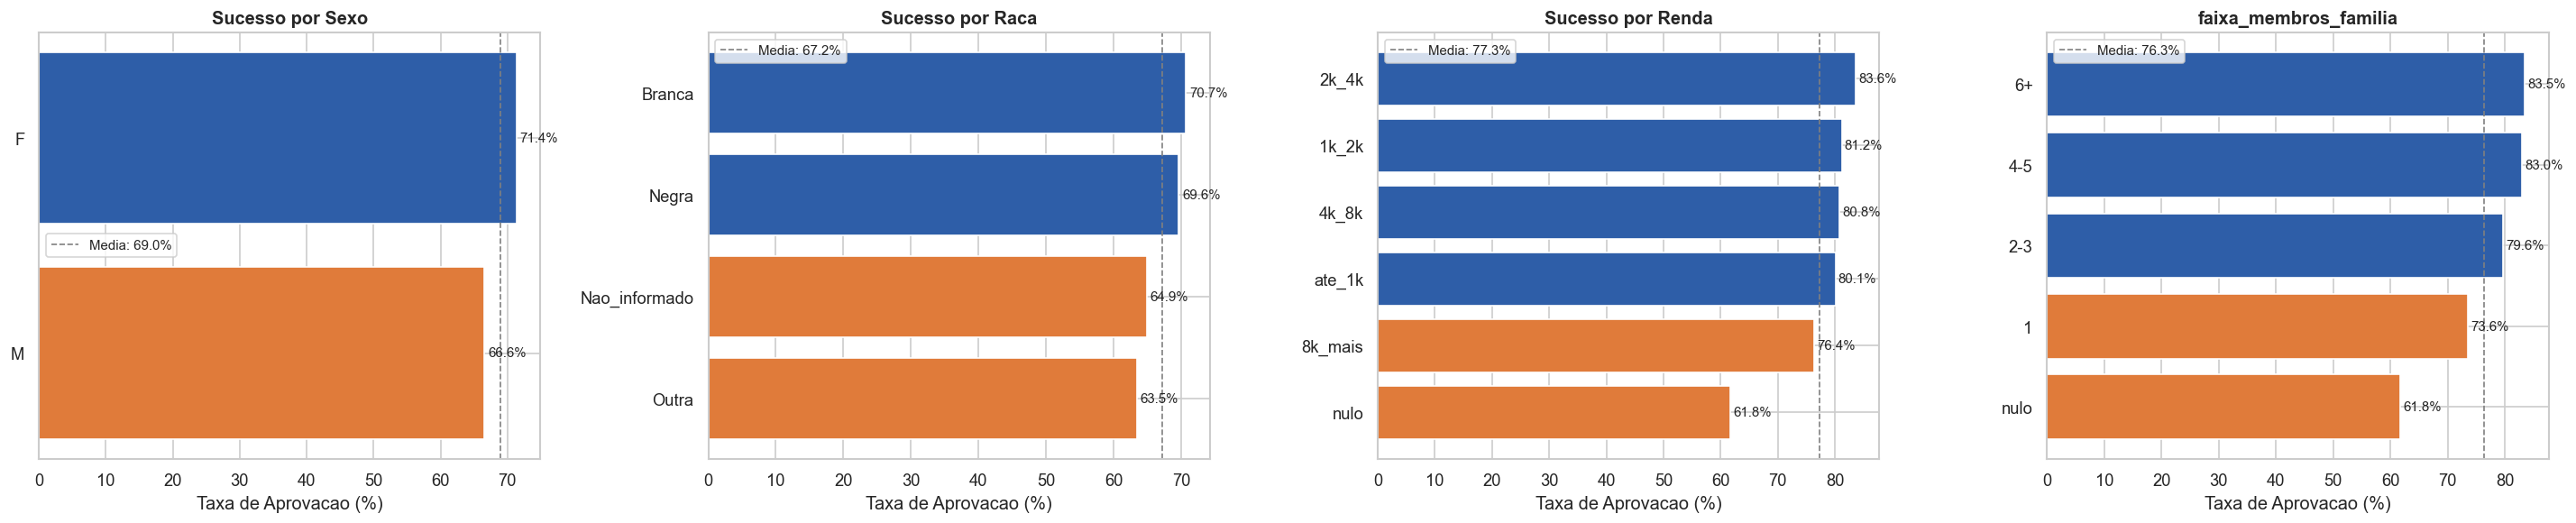

In [229]:
cols_perfil = [c for c in ['sexo', 'raca_declarada', 'faixa_renda_familiar', 'faixa_membros_familia'] if c in df_modelo.columns]
if cols_perfil:
    fig, axes = plt.subplots(1, len(cols_perfil), figsize=(6*len(cols_perfil), 5))
    if len(cols_perfil) == 1: axes = [axes]
    titulos = {'sexo':'Sucesso por Sexo','raca_declarada':'Sucesso por Raca','faixa_renda_familiar':'Sucesso por Renda'}
    for ax, col in zip(axes, cols_perfil):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str), taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--', linewidth=1, label=f'Media: {taxa.mean():.1f}%')
        ax.set_xlabel('Taxa de Aprovacao (%)')
        ax.set_title(titulos.get(col, col), fontweight='bold')
        ax.legend(fontsize=9)
        for bar, val in zip(bars, taxa.values):
            ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig1_taxa_sucesso_perfil_aluno.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('ops')

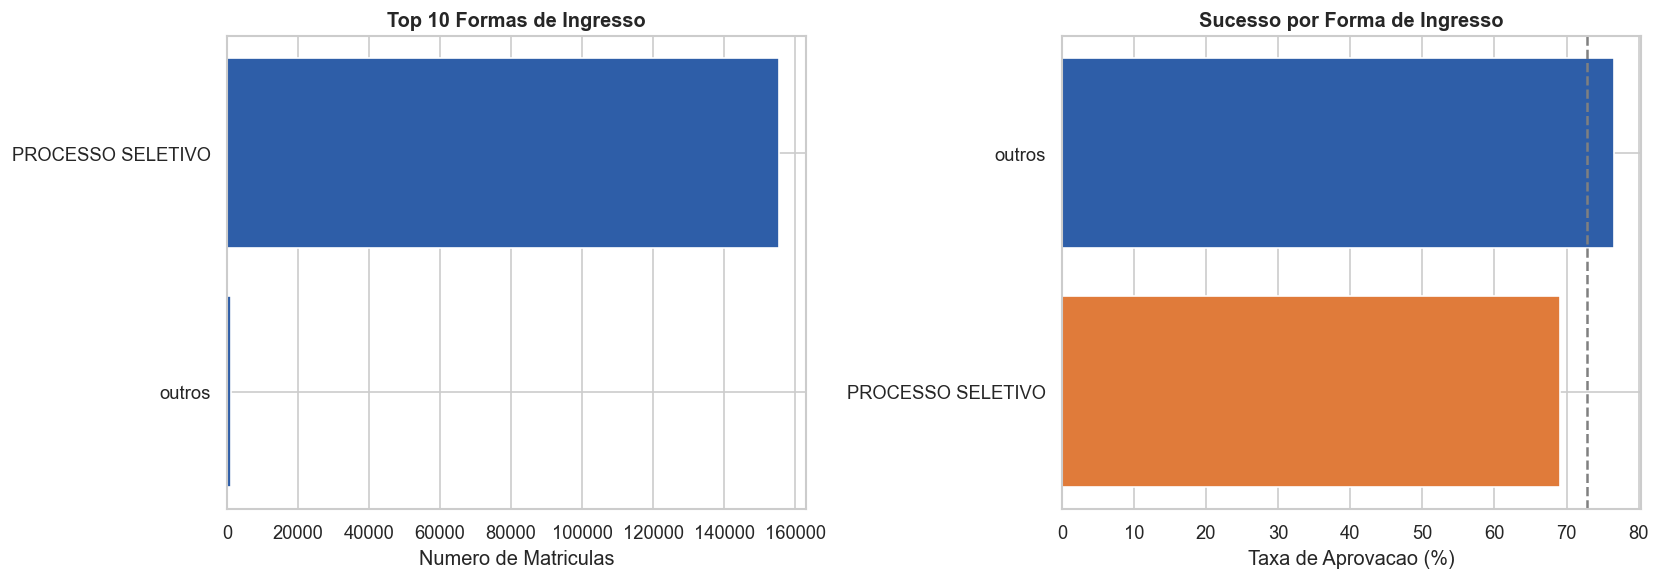

In [230]:
if 'forma_ingresso' in df_modelo.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    forma_counts = df_modelo['forma_ingresso'].value_counts().head(10)
    axes[0].barh(forma_counts.index[::-1], forma_counts.values[::-1], color='#2E5EA8')
    axes[0].set_xlabel('Numero de Matriculas')
    axes[0].set_title('Top 10 Formas de Ingresso', fontweight='bold')
    taxa_ing = df_modelo.groupby('forma_ingresso')['target'].mean().sort_values().tail(10) * 100
    colors = ['#2E5EA8' if v >= taxa_ing.mean() else '#E07B3A' for v in taxa_ing.values]
    axes[1].barh(taxa_ing.index, taxa_ing.values, color=colors)
    axes[1].axvline(taxa_ing.mean(), color='gray', linestyle='--')
    axes[1].set_xlabel('Taxa de Aprovacao (%)')
    axes[1].set_title('Sucesso por Forma de Ingresso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig2_forma_ingresso.png', dpi=150, bbox_inches='tight')
    plt.show()

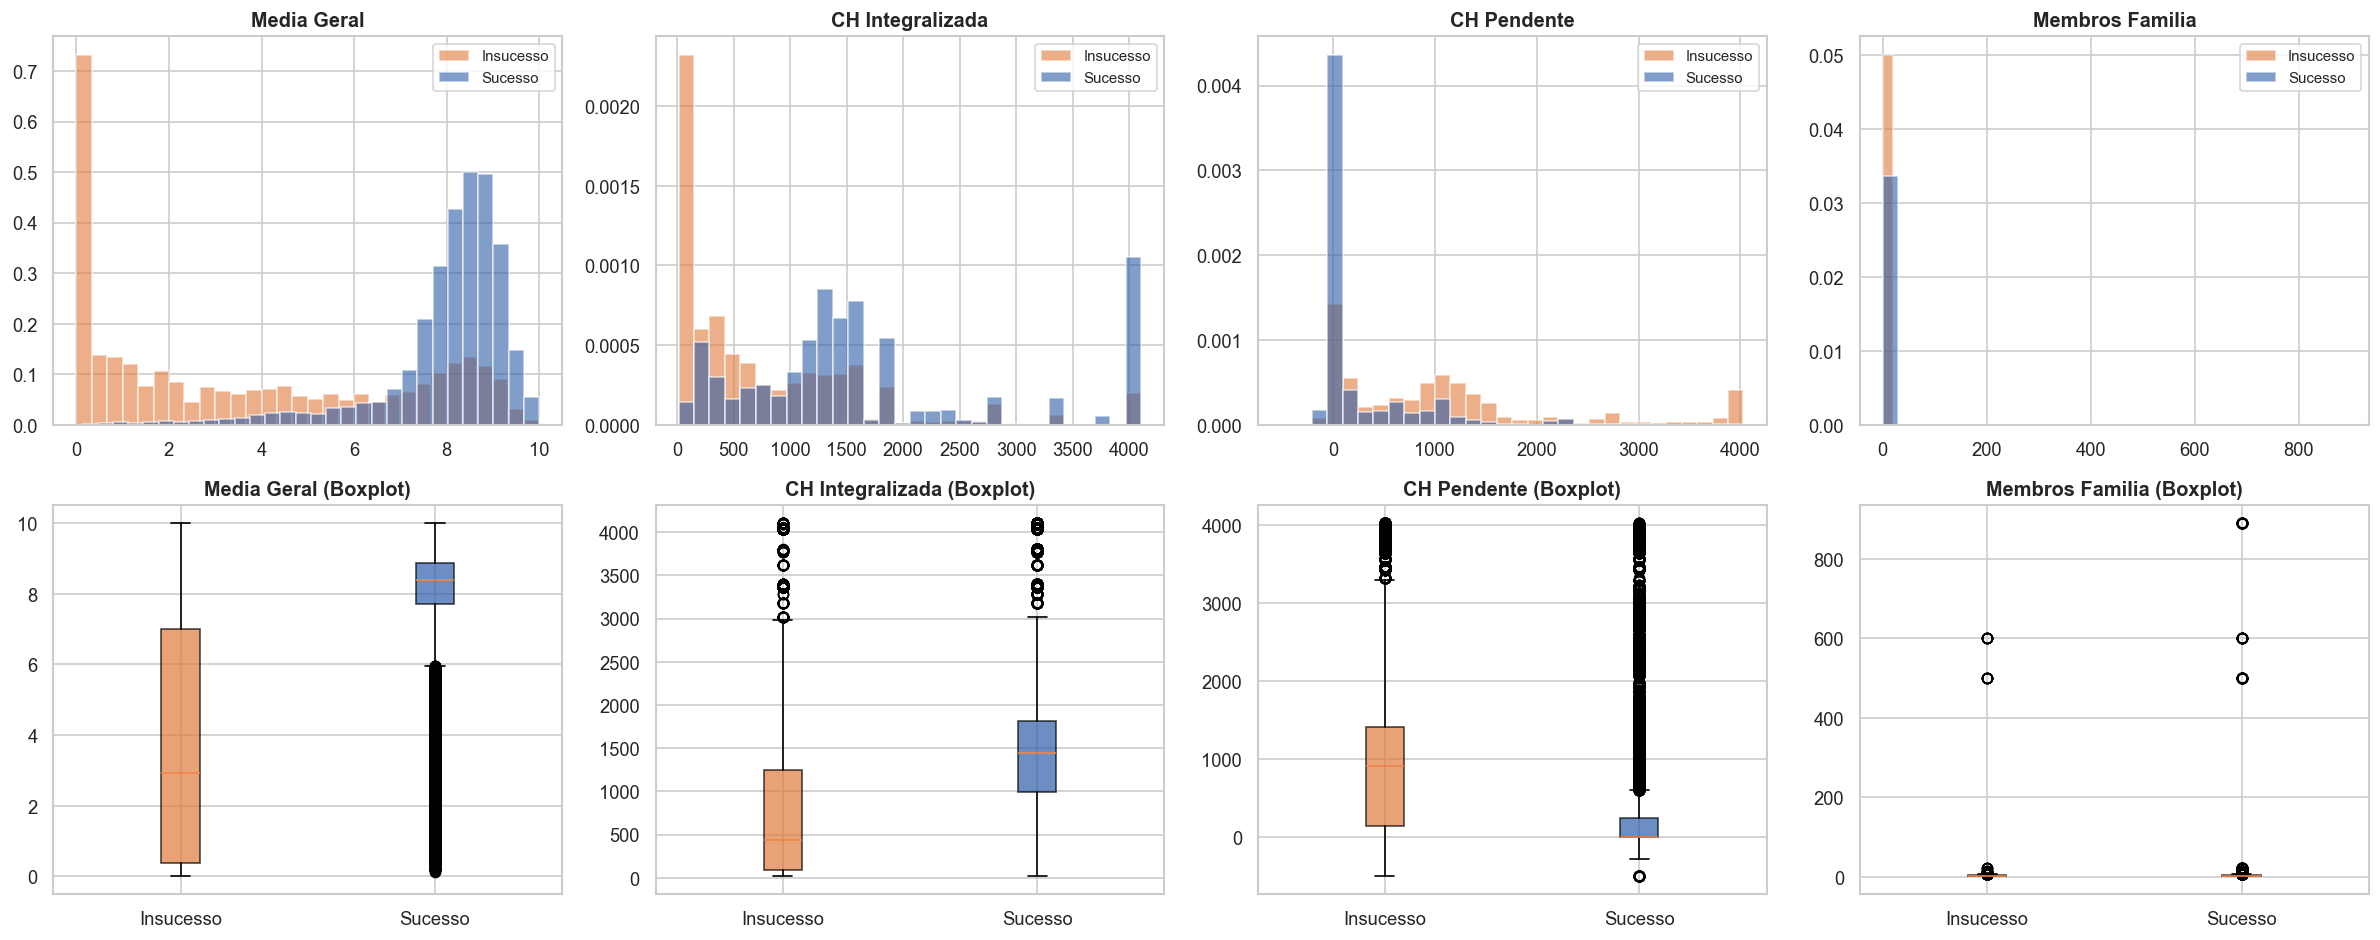

In [231]:
num_aluno = [(c, l) for c, l in [
    ('media_geral','Media Geral'),('ch_integralizada','CH Integralizada'),
    ('ch_pendente','CH Pendente'),('quantidade_membros_familia','Membros Familia')
] if c in df_modelo.columns]

if num_aluno:
    cols_p, labs_p = zip(*num_aluno)
    n = len(cols_p)
    fig, axes = plt.subplots(2, n, figsize=(5*n, 8))
    if n == 1: axes = axes.reshape(2,1)
    for i, (col, label) in enumerate(zip(cols_p, labs_p)):
        for cls, color, lbl in [(0,'#E07B3A','Insucesso'),(1,'#2E5EA8','Sucesso')]:
            subset = df_modelo[df_modelo['target']==cls][col].dropna()
            axes[0,i].hist(subset, bins=30, alpha=0.6, color=color, label=lbl, density=True)
        axes[0,i].set_title(label, fontweight='bold'); axes[0,i].legend(fontsize=9)
        data = [df_modelo[df_modelo['target']==cls][col].dropna() for cls in [0,1]]
        bp = axes[1,i].boxplot(data, patch_artist=True, labels=['Insucesso','Sucesso'])
        for patch, color in zip(bp['boxes'], ['#E07B3A','#2E5EA8']):
            patch.set_facecolor(color); patch.set_alpha(0.7)
        axes[1,i].set_title(f'{label} (Boxplot)', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig3_distribuicoes_numericas.png', dpi=150, bbox_inches='tight')
    plt.show()

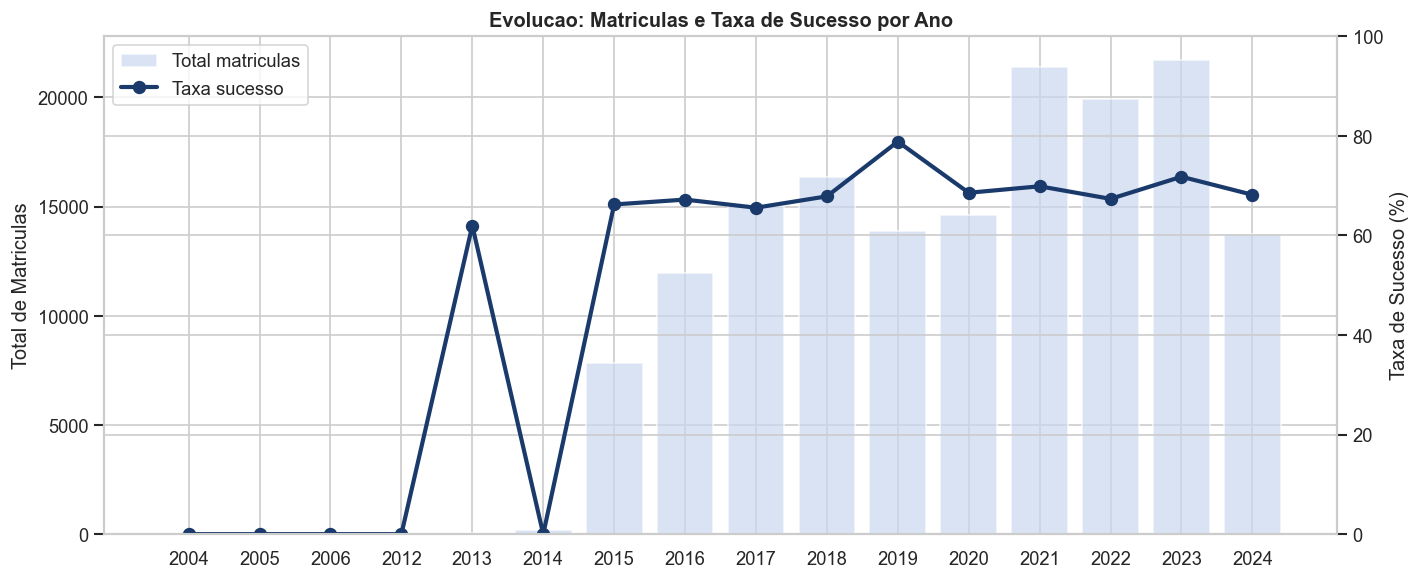

In [232]:
if 'ano' in df_modelo.columns:
    taxa_ano = df_modelo.groupby('ano')['target'].agg(['mean','count']).reset_index()
    taxa_ano.columns = ['ano','taxa_sucesso','total']
    taxa_ano['taxa_sucesso'] *= 100
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax2 = ax1.twinx()
    ax1.bar(taxa_ano['ano'], taxa_ano['total'], color='#CBD8EF', alpha=0.7, label='Total matriculas')
    ax2.plot(taxa_ano['ano'], taxa_ano['taxa_sucesso'], 'o-', color='#1A3A6B', lw=2.5, ms=7, label='Taxa sucesso')
    ax1.set_ylabel('Total de Matriculas'); ax2.set_ylabel('Taxa de Sucesso (%)'); ax2.set_ylim(0,100)
    l1, la1 = ax1.get_legend_handles_labels(); l2, la2 = ax2.get_legend_handles_labels()
    ax1.legend(l1+l2, la1+la2, loc='upper left')
    plt.title('Evolucao: Matriculas e Taxa de Sucesso por Ano', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig4_evolucao_temporal.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.2 Dimensão Currículo

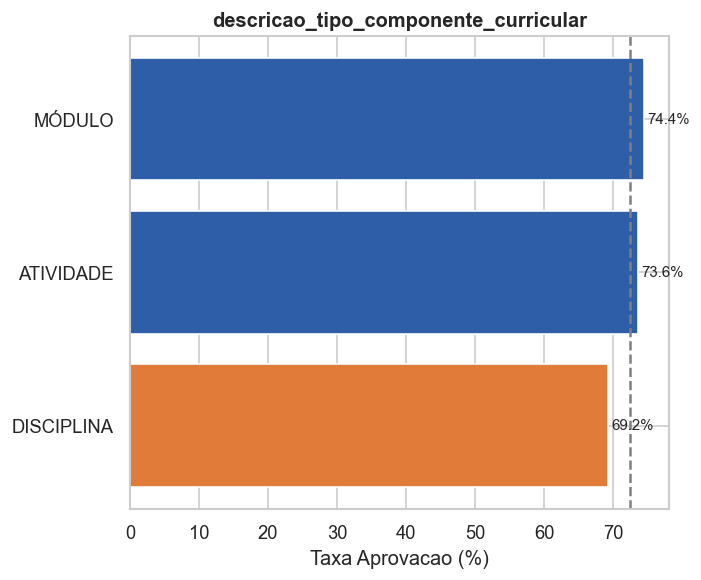

In [233]:
cols_curr = [c for c in ['campus','nivel_componente_curricular','descricao_tipo_componente_curricular'] if c in df_modelo.columns]
if cols_curr:
    fig, axes = plt.subplots(1, len(cols_curr), figsize=(6*len(cols_curr), 5))
    if len(cols_curr) == 1: axes = [axes]
    for ax, col in zip(axes, cols_curr):
        taxa = df_modelo.groupby(col)['target'].mean().sort_values() * 100
        taxa = taxa.head(12)
        colors = ['#2E5EA8' if v >= taxa.mean() else '#E07B3A' for v in taxa.values]
        bars = ax.barh(taxa.index.astype(str), taxa.values, color=colors)
        ax.axvline(taxa.mean(), color='gray', linestyle='--')
        ax.set_xlabel('Taxa Aprovacao (%)'); ax.set_title(col, fontweight='bold')
        for bar, val in zip(bars, taxa.values):
            ax.text(val+0.5, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig5_taxa_sucesso_curriculo.png', dpi=150, bbox_inches='tight')
    plt.show()

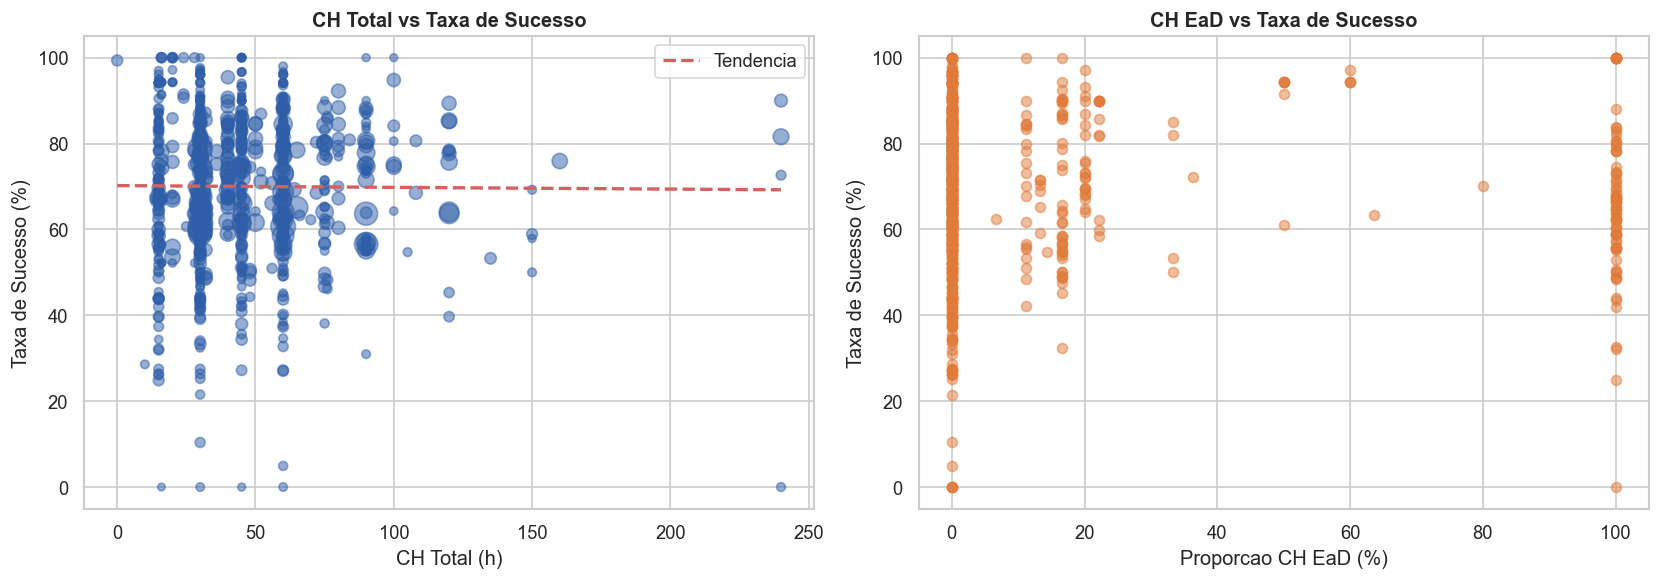

In [234]:
if {'id_disciplina','ch_total','ch_ead'}.issubset(df_modelo.columns):
    comp_taxa = df_modelo.groupby('id_disciplina').agg(
        taxa_sucesso=('target','mean'), ch_total=('ch_total','first'),
        ch_ead=('ch_ead','first'), total=('target','count')
    ).reset_index()
    comp_taxa = comp_taxa[comp_taxa['total'] >= 5]
    comp_taxa['prop_ead'] = comp_taxa['ch_ead'] / (comp_taxa['ch_total'] + 1e-6)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(comp_taxa['ch_total'], comp_taxa['taxa_sucesso']*100, alpha=0.5,
                    s=comp_taxa['total']/comp_taxa['total'].max()*200+20, color='#2E5EA8')
    valid = comp_taxa[['ch_total','taxa_sucesso']].dropna()
    if len(valid) > 1:
        p = np.poly1d(np.polyfit(valid['ch_total'], valid['taxa_sucesso']*100, 1))
        xl = np.linspace(valid['ch_total'].min(), valid['ch_total'].max(), 100)
        axes[0].plot(xl, p(xl), 'r--', lw=2, label='Tendencia')
    axes[0].set_xlabel('CH Total (h)'); axes[0].set_ylabel('Taxa de Sucesso (%)')
    axes[0].set_title('CH Total vs Taxa de Sucesso', fontweight='bold'); axes[0].legend()

    axes[1].scatter(comp_taxa['prop_ead']*100, comp_taxa['taxa_sucesso']*100, alpha=0.5, color='#E07B3A')
    axes[1].set_xlabel('Proporcao CH EaD (%)'); axes[1].set_ylabel('Taxa de Sucesso (%)')
    axes[1].set_title('CH EaD vs Taxa de Sucesso', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig6_ch_vs_taxa.png', dpi=150, bbox_inches='tight')
    plt.show()

### 5.3 Dimensão Professor

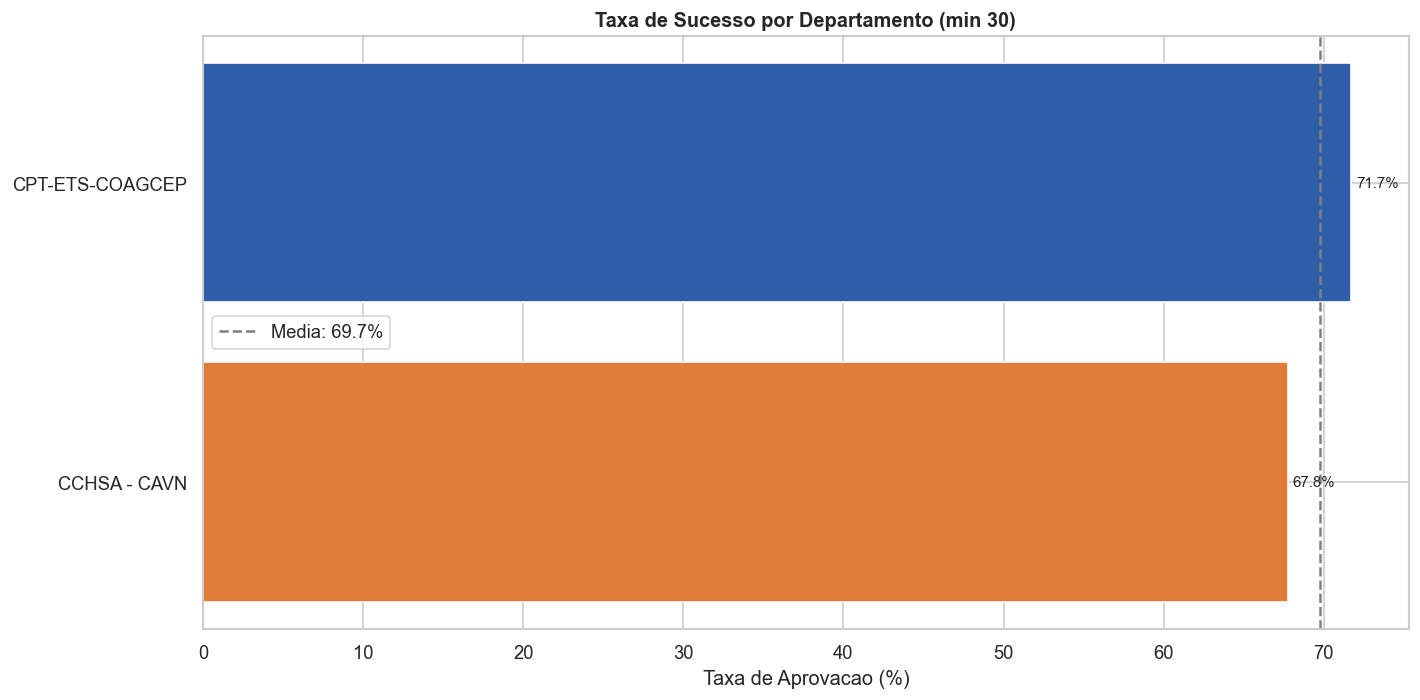

In [235]:
if 'sigla_departamento' in df_modelo.columns:
    taxa_dept = df_modelo.groupby('sigla_departamento').agg(
        taxa_sucesso=('target','mean'), total=('target','count')
    ).reset_index()
    taxa_dept = taxa_dept[taxa_dept['total'] >= 30].sort_values('taxa_sucesso')
    taxa_dept['taxa_sucesso'] *= 100
    fig, ax = plt.subplots(figsize=(12, max(6, len(taxa_dept)*0.4)))
    colors = ['#2E5EA8' if v >= taxa_dept['taxa_sucesso'].mean() else '#E07B3A' for v in taxa_dept['taxa_sucesso']]
    bars = ax.barh(taxa_dept['sigla_departamento'], taxa_dept['taxa_sucesso'], color=colors)
    ax.axvline(taxa_dept['taxa_sucesso'].mean(), color='gray', linestyle='--', lw=1.5,
               label=f'Media: {taxa_dept["taxa_sucesso"].mean():.1f}%')
    ax.set_xlabel('Taxa de Aprovacao (%)'); ax.set_title('Taxa de Sucesso por Departamento (min 30)', fontweight='bold')
    ax.legend()
    for bar, val in zip(bars, taxa_dept['taxa_sucesso']):
        ax.text(val+0.3, bar.get_y()+bar.get_height()/2, f'{val:.1f}%', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig7_taxa_departamento.png', dpi=150, bbox_inches='tight')
    plt.show()

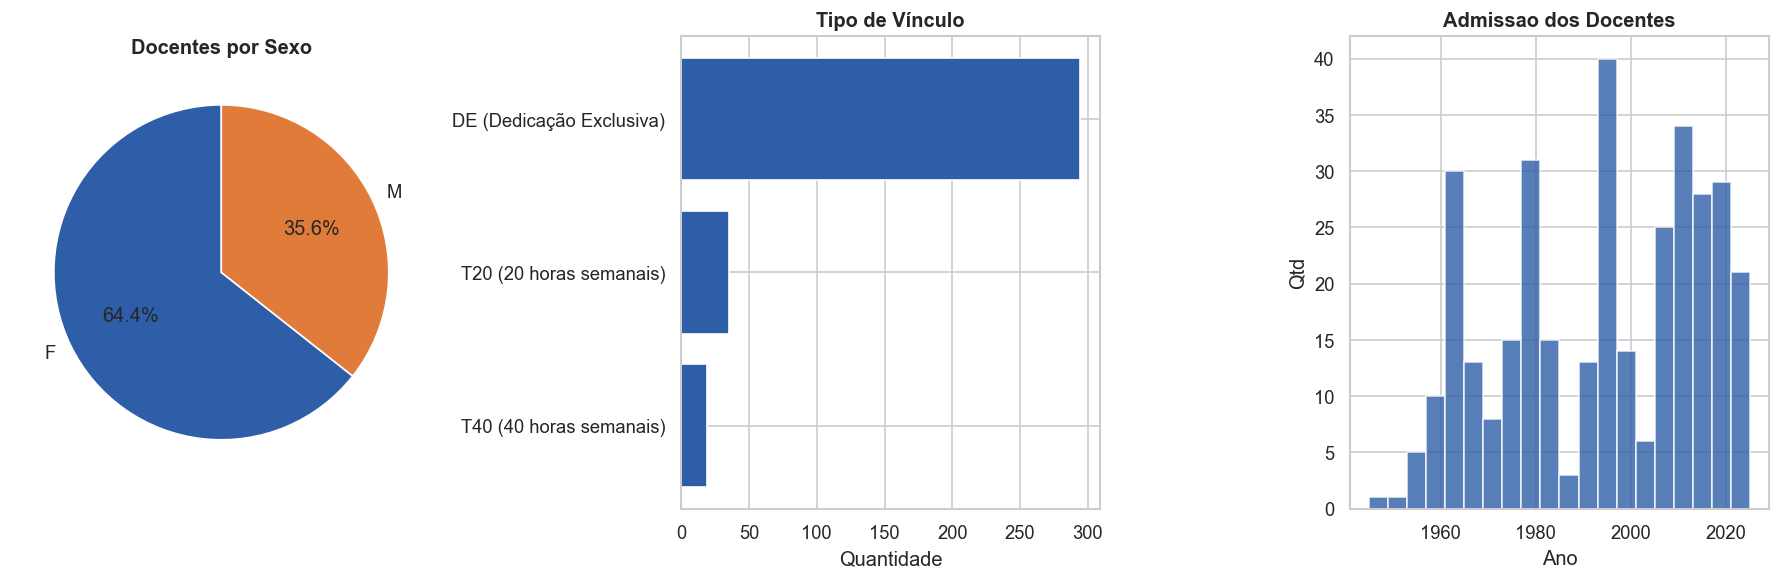

Total docentes: 348


In [236]:
cols_doc = [c for c in ['sexo','tipo_vinculo','ano_admissao'] if c in docentes.columns]
if cols_doc:
    fig, axes = plt.subplots(1, len(cols_doc), figsize=(5*len(cols_doc), 5))
    if len(cols_doc) == 1: axes = [axes]
    for i, col in enumerate(cols_doc):
        ax = axes[i]
        if col == 'sexo':
            vc2 = docentes['sexo'].value_counts()
            ax.pie(vc2.values, labels=vc2.index, autopct='%1.1f%%', colors=['#2E5EA8','#E07B3A'], startangle=90)
            ax.set_title('Docentes por Sexo', fontweight='bold')
        elif col == 'tipo_vinculo':
            col_plot = 'tipo_vinculo_label' if 'tipo_vinculo_label' in docentes.columns else 'tipo_vinculo'
            vc2 = docentes[col_plot].value_counts().head(6)
            ax.barh(vc2.index[::-1], vc2.values[::-1], color='#2E5EA8')
            ax.set_xlabel('Quantidade'); ax.set_title('Tipo de Vínculo', fontweight='bold')
        elif col == 'ano_admissao':
            docentes['ano_admissao'].dropna().hist(bins=20, color='#2E5EA8', alpha=0.8, ax=ax)
            ax.set_xlabel('Ano'); ax.set_ylabel('Qtd'); ax.set_title('Admissao dos Docentes', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig8_perfil_docente.png', dpi=150, bbox_inches='tight')
    plt.show()
print(f'Total docentes: {len(docentes)}')

### 5.4 Análise da Variável-Alvo

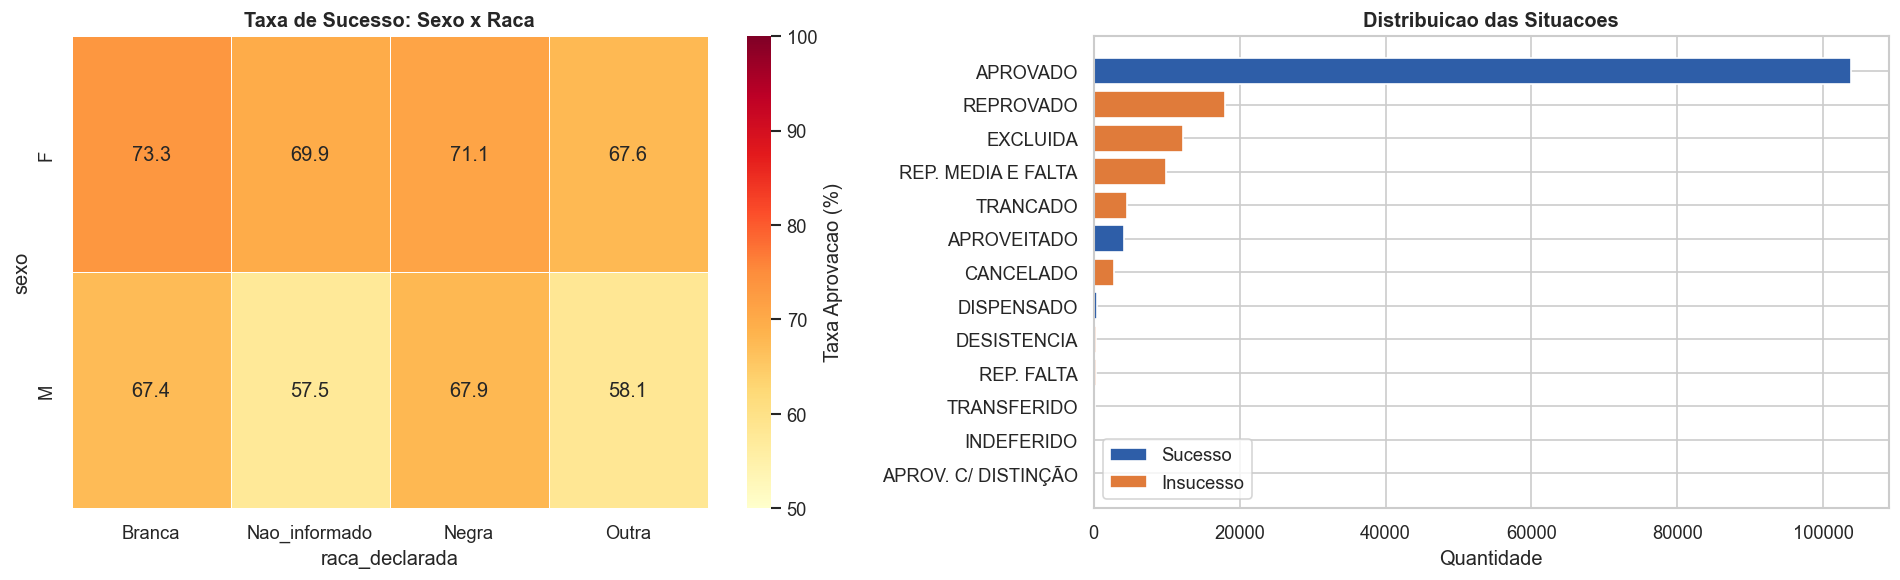

In [237]:
if {'sexo','raca_declarada'}.issubset(df_modelo.columns):
    pivot = df_modelo.groupby(['sexo','raca_declarada'])['target'].mean().unstack() * 100
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0], linewidths=0.5,
                vmin=50, vmax=100, cbar_kws={'label': 'Taxa Aprovacao (%)'})
    axes[0].set_title('Taxa de Sucesso: Sexo x Raca', fontweight='bold')
    sit_counts = df_modelo['situacao'].value_counts()
    colors_map = ['#2E5EA8' if s in SITUACOES_SUCESSO else '#E07B3A' for s in sit_counts.index]
    axes[1].barh(sit_counts.index[::-1], sit_counts.values[::-1], color=colors_map[::-1])
    axes[1].set_xlabel('Quantidade')
    axes[1].set_title('Distribuicao das Situacoes', fontweight='bold')
    axes[1].legend(handles=[Patch(facecolor='#2E5EA8',label='Sucesso'),Patch(facecolor='#E07B3A',label='Insucesso')])
    plt.tight_layout()
    plt.savefig('fig9_analise_alvo.png', dpi=150, bbox_inches='tight')
    plt.show()

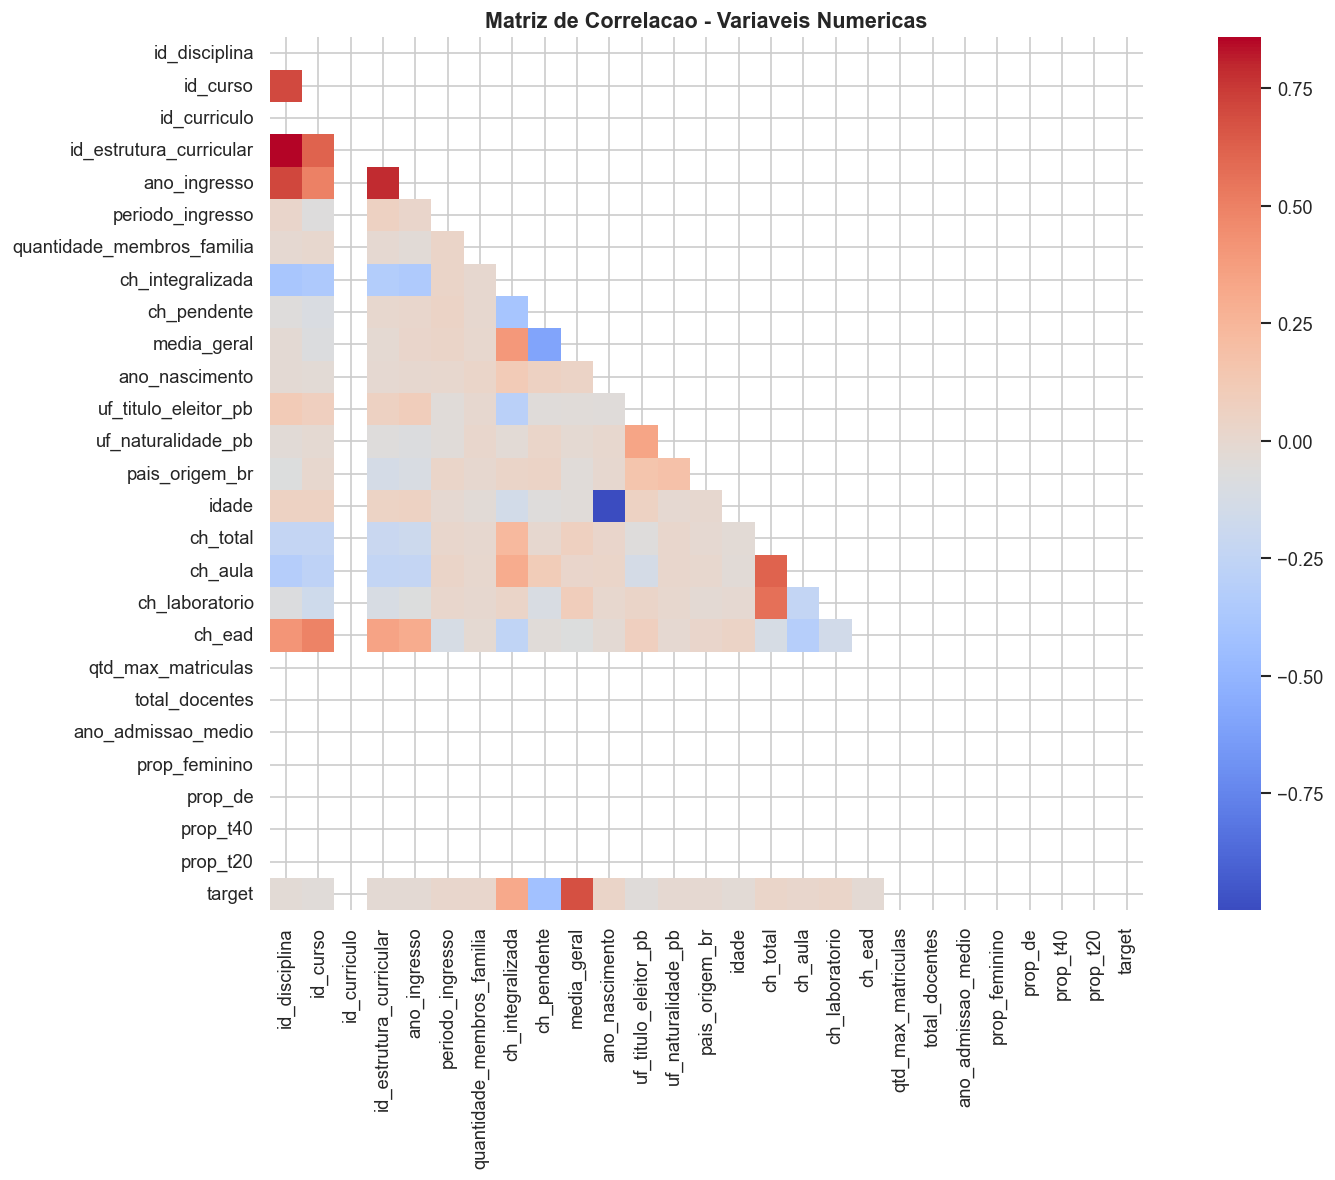

In [238]:
num_cols = df_modelo.select_dtypes(include='number').columns
corr_matrix = df_modelo[num_cols].corr()
fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, fmt='.2f', cmap='coolwarm',
     square=True,
)
ax.set_title('Matriz de Correlacao - Variaveis Numericas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('fig10_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Pré-processamento e Feature Engineering

In [224]:
dicionario_areas = {
    'NOÇÕES DE PRIMEIROS SOCORROS': 'Ciências da Saúde',
    'NOÇÕES DE ANATOMIA E FISIOLOGIA HUMANA': 'Ciências Biológicas',
    'NOÇÕES DE MICROBIOLOGIA, PARASITOLOGIA E IMUNOLOGIA': 'Ciências Biológicas',
    'EDUCAÇÃO EM SAÚDE': 'Ciências da Saúde',
    'PSICOLOGIA APLICADA À SAÚDE': 'Ciências Humanas e Sociais Aplicadas',
    'ÉTICA EM SAÚDE': 'Ciências Humanas e Sociais Aplicadas',
    'INTRODUÇÃO À MICROINFORMÁTICA': 'Tecnologia da Informação',
    'ANATOMIA E FISIOLOGIA DA CABEÇA E PESCOÇO': 'Ciências da Saúde',
    'ÉTICA PROFISSIONAL E LEGISLAÇÃO TRABALHISTA': 'Ciências Humanas e Sociais Aplicadas',
    'BIOSSEGURANÇA': 'Ciências da Saúde',
    'ANATOMIA E ESCULTURA DENTAL I E II': 'Ciências da Saúde',
    'ANATOMIA E ESCULTURA DENTAL II': 'Ciências da Saúde',
    'MATERIAIS DENTÁRIOS': 'Ciências da Saúde',
    'PRÓTESE FIXA I': 'Ciências da Saúde',
    'PRÓTESE FIXA II': 'Ciências da Saúde',
    'PRÓTESE FIXA III': 'Ciências da Saúde',
    'PRÓTESE FIXA IV': 'Ciências da Saúde',
    'PRÓTESE PARCIAL REMOVÍVEL': 'Ciências da Saúde',
    'PRÓTESE TOTAL I E II': 'Ciências da Saúde',
    'INTRODUÇÃO À PRÓTESE DENTÁRIA': 'Ciências da Saúde',
    'PRÓTESE ORTODÔNTICA': 'Ciências da Saúde',
    'MOLDES E MODELOS': 'Ciências da Saúde',
    'OCLUSÃO DENTAL': 'Ciências da Saúde',
    'ADMINISTRAÇÃO': 'Ciências Humanas e Sociais Aplicadas',
    'ESTÁGIO SUPERVISIONADO OCLUSÃO': 'Multidisciplinar',
    'NOÇÕES DE ANATOMIA E FISIOLOGIA DO SISTEMA ESTOMATOGNÁTICO': 'Ciências da Saúde',
    'ÉTICA E LEGISLAÇÃO': 'Ciências Humanas e Sociais Aplicadas',
    'BIOSSEGURANÇA E ERGONOMIA NO LABORATÓRIO DE PRÓTESE DENTÁRIA': 'Ciências da Saúde',
    'INICIAÇÃO À PESQUISA CIENTÍFICA': 'Multidisciplinar',
    'INTRODUÇÃO AO ESTUDO DOS MATERIAIS DENTÁRIOS': 'Ciências da Saúde',
    'ANATOMIA E ESCULTURA DENTAL I': 'Ciências da Saúde',
    'OCLUSÃO': 'Ciências da Saúde',
    'PRÓTESE TOTAL I': 'Ciências da Saúde',
    'PROTESE FIXA I': 'Ciências da Saúde',
    'PRÓTESE TOTAL II': 'Ciências da Saúde',
    'PRÓTESE PARCIAL REMOVÍVEL I': 'Ciências da Saúde',
    'ORTODONTIA LABORATORIAL': 'Ciências da Saúde',
    'PRÓTESE PARCIAL REMOVÍVEL II': 'Ciências da Saúde',
    'NOÇÕES DE ADMINISTRAÇÃO DOS SERVIÇOS EM LABOLATÓRIO DE PRÓTESE DENTÁRIA': 'Ciências Humanas e Sociais Aplicadas',
    'NOÇÕES DE PRÓTESE SOBRE IMPLANTE': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO PRÓTESE TOTAL': 'Multidisciplinar',
    'ANATOMIA DE SISTEMAS': 'Ciências Biológicas',
    'HISTOLOGIA I': 'Ciências Biológicas',
    'HISTOLOGIA II': 'Ciências Biológicas',
    'ÉTICA E LEGISLAÇÃO PROFISSIONAL': 'Ciências Humanas e Sociais Aplicadas',
    'NOÇÕES DE PATOLOGIA GERAL': 'Ciências Biológicas',
    'BIOSEGURANÇA EM LABORATÓRIO': 'Ciências da Saúde',
    'MICROSCOPIA ÓPTICA I': 'Ciências Biológicas',
    'INSTRUMENTAÇÃO LABORATORIAL': 'Ciências da Saúde',
    'PROCESSAMENTO DE TECIDOS MOLES PARA MICROSCOPIA ÓPTICA I': 'Ciências Biológicas',
    'PROCESSAMENTO DE TECIDOS MOLES PARA MICROSCOPIA ÓPTICA II': 'Ciências Biológicas',
    'ORGANIZAÇÃO DO TRABALHO LABORATORIAL': 'Ciências Humanas e Sociais Aplicadas',
    'PROCESSAMENTO E ANÁLISE DE IMAGEM DIGITAL': 'Tecnologia da Informação',
    'PROCESSAMENTO DE TECIDOS DUROS PARA MICROSCOPIA ÓPTICA': 'Ciências Biológicas',
    'MICROSCOPIA ÓPTICA II': 'Ciências Biológicas',
    'PROCESSAMENTO DE TECIDOS PARA MICROSCOPIA ELETÔNICA': 'Ciências Biológicas',
    'VÍDEO DIGITAL EM MICROSCOPIA': 'Tecnologia da Informação',
    'PRÁTICA LABORATORIAL INTEGRADA': 'Multidisciplinar',
    'NOÇÕES DE PESQUISA EM ENFERMAGEM': 'Ciências da Saúde',
    'LEGISLAÇÃO EM ENFERMAGEM': 'Ciências da Saúde',
    'FUNDAMENTOS EM ENFERMAGEM I': 'Ciências da Saúde',
    'INFORMÁTICA APLICADA À ENFERMAGEM': 'Ciências da Saúde',
    'BIOÉTICA APLICADA À ENFERMAGEM': 'Ciências da Saúde',
    'FUNDAMENTOS DE ENFERMAGEM I': 'Ciências da Saúde',
    'ENFERMAGEM CLÍNICA': 'Ciências da Saúde',
    'ENFERMAGEM NA SAÚDE DA MULHER': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO: ÁREA ENFERMAGEM NA SAÚDE DA MULHER': 'Multidisciplinar',
    'ENFERMAGEM NA SAÚDE DA CRIANÇA E DO ADOLESCENTE': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO: ÁREA SAÚDE DA CRIANÇA E DO ADOLESCENTE': 'Multidisciplinar',
    'ENFERMAGEM EM SAÚDE MENTAL': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO: ÁREA ENFERMAGEM EM SAÚDE MENTAL': 'Multidisciplinar',
    'ENFERMAGEM EM SAÚDE COLETIVA': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO: ÁREA ENFERMAGEM EM SAÚDE COLETIVA': 'Multidisciplinar',
    'ENFERMAGEM EM EMERGÊNCIAS': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO: ÁREA ENFERMAGEM EM EMERGÊNCIAS': 'Multidisciplinar',
    'ENFERMAGEM EM UTI': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO: ÁREA ENFERMAGEM EM UTI': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO III': 'Multidisciplinar',
    'SAÚDE COLETIVA': 'Ciências da Saúde',
    'FUNDAMENTOS DE ENFERMAGEM II': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO: ÁREA ENFERMAGEM CLÍNICA': 'Multidisciplinar',
    'ENFERMAGEM CIRÚRGICA': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO: ÁREA ENFERMAGEM CIRÚRGICA': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO PRÓTESE FIXA I': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO PRÓTESE FIXA II': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO PRÓTESE FIXA III': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO PRÓTESE PARCIAL REMOVÍVEL': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO ORTODONTIA LABORATORIAL': 'Multidisciplinar',
    'LÍNGUA PORTUGUESA - 1º ANO': 'Linguística, Letras e Artes',
    'LÍNGUA PORTUGUESA - 2º ANO': 'Linguística, Letras e Artes',
    'LÍNGUA PORTUGUESA - 3º ANO': 'Linguística, Letras e Artes',
    'EDUCAÇÃO FÍSICA - 1º ANO': 'Multidisciplinar',
    'EDUCAÇÃO FÍSICA - 2º ANO': 'Multidisciplinar',
    'EDUCAÇÃO FÍSICA - 3º ANO': 'Multidisciplinar',
    'ARTE - 1º ANO': 'Linguística, Letras e Artes',
    'ARTE - 2º ANO': 'Linguística, Letras e Artes',
    'MATEMÁTICA - 1º ANO': 'Ciências Exatas e da Terra',
    'MATEMÁTICA - 2º ANO': 'Ciências Exatas e da Terra',
    'MATEMÁTICA - 3º ANO': 'Ciências Exatas e da Terra',
    'BIOLOGIA - 1º ANO': 'Ciências Biológicas',
    'BIOLOGIA - 2º ANO': 'Ciências Biológicas',
    'BIOLOGIA - 3º ANO': 'Ciências Biológicas',
    'FÍSICA - 1º ANO': 'Ciências Exatas e da Terra',
    'FÍSICA - 2º ANO': 'Ciências Exatas e da Terra',
    'FÍSICA - 3º ANO': 'Ciências Exatas e da Terra',
    'QUÍMICA - 1º ANO': 'Ciências Exatas e da Terra',
    'QUÍMICA - 2º ANO': 'Ciências Exatas e da Terra',
    'QUÍMICA - 3º ANO': 'Ciências Exatas e da Terra',
    'HISTÓRIA - 1º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA - 2º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA - 3º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 1º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 2º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 3º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 1º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 2º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 3º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 1º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 2º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 3º ANO': 'Ciências Humanas e Sociais Aplicadas',
    'ESPANHOL - 1º ANO': 'Linguística, Letras e Artes',
    'ESPANHOL - 2º ANO': 'Linguística, Letras e Artes',
    'ESPANHOL - 3º ANO': 'Linguística, Letras e Artes',
    'INFORMÁTICA - 1º ANO': 'Tecnologia da Informação',
    'INFORMÁTICA - 2º ANO': 'Tecnologia da Informação',
    'LÍNGUA PORTUGUESA - 1º ANO - PROEJA': 'Linguística, Letras e Artes',
    'LÍNGUA PORTUGUESA - 2º ANO - PROEJA': 'Linguística, Letras e Artes',
    'LÍNGUA PORTUGUESA - 3º ANO - PROEJA': 'Linguística, Letras e Artes',
    'EDUCAÇÃO FÍSICA - 1º ANO - PROEJA': 'Multidisciplinar',
    'EDUCAÇÃO FÍSICA - 2º ANO - PROEJA': 'Multidisciplinar',
    'EDUCAÇÃO FÍSICA - 3º ANO - PROEJA': 'Multidisciplinar',
    'ARTE - 1º ANO - PROEJA': 'Linguística, Letras e Artes',
    'ARTE - 2º ANO - PROEJA': 'Linguística, Letras e Artes',
    'MATEMÁTICA - 1º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'MATEMÁTICA - 2º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'MATEMÁTICA - 3º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'BIOLOGIA - 1º ANO - PROEJA': 'Ciências Biológicas',
    'BIOLOGIA - 2º ANO - PROEJA': 'Ciências Biológicas',
    'BIOLOGIA - 3º ANO - PROEJA': 'Ciências Biológicas',
    'FÍSICA - 1º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'FÍSICA - 2º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'FÍSICA - 3º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'QUÍMICA - 1º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'QUÍMICA - 2º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'QUÍMICA - 3º ANO - PROEJA': 'Ciências Exatas e da Terra',
    'HISTÓRIA - 1º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA - 2º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA - 3º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 1º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 2º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 3º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 1º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 2º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 3º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 1º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 2º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 3º ANO - PROEJA': 'Ciências Humanas e Sociais Aplicadas',
    'ESPANHOL - 1º ANO - PROEJA': 'Linguística, Letras e Artes',
    'ESPANHOL - 2º ANO - PROEJA': 'Linguística, Letras e Artes',
    'ESPANHOL - 3º ANO - PROEJA': 'Linguística, Letras e Artes',
    'INFORMÁTICA - 1º ANO - PROEJA': 'Tecnologia da Informação',
    'INFORMÁTICA - 2º ANO - PROEJA': 'Tecnologia da Informação',
    'JARDINAGEM': 'Ciências Agrárias',
    'OLERICULTURA': 'Ciências Agrárias',
    'FITOSSANIDADE': 'Ciências Agrárias',
    'SILVICULTURA': 'Ciências Agrárias',
    'TOPOGRAFIA': 'Ciências Exatas e da Terra',
    'INTRODUÇÃO À AGROINDÚSTRIA': 'Ciências Agrárias',
    'SOLOS': 'Ciências Agrárias',
    'IRRIGAÇÃO E DRENAGEM': 'Ciências Agrárias',
    'FRUTICULTURA': 'Ciências Agrárias',
    'MECANIZAÇÃO AGRÍCOLA': 'Ciências Agrárias',
    'COLHEITA E PÓS-COLHEITA': 'Ciências Agrárias',
    'CULTURAS': 'Ciências Agrárias',
    'APICULTURA': 'Ciências Agrárias',
    'CUNICULTURA': 'Ciências Agrárias',
    'RANICULTURA': 'Ciências Agrárias',
    'PISCICULTURA': 'Ciências Agrárias',
    'CONSTRUÇÕES RURAIS': 'Ciências Agrárias',
    'PASTAGEM': 'Ciências Agrárias',
    'SUINOCULTURA': 'Ciências Agrárias',
    'AVICULTURA': 'Ciências Agrárias',
    'BOVINOCULTURA': 'Ciências Agrárias',
    'CAPRINO-OVINOCULTURA': 'Ciências Agrárias',
    'PLANEJAMENTO E PROJETOS': 'Ciências Humanas e Sociais Aplicadas',
    'GESTÃO E EXTENSÃO RURAL': 'Ciências Humanas e Sociais Aplicadas',
    'ESTÁGIO SUPERVISIONADO EM AGROPECUÁRIA': 'Multidisciplinar',
    'FATORES DE PRODUÇÃO ANIMAL': 'Ciências Agrárias',
    'FATORES DE PRODUÇÃO VEGETAL': 'Ciências Agrárias',
    'HIGIENE E SANITIZAÇÃO NA AGROINDÚSTRIA': 'Ciências Agrárias',
    'ORGANIZAÇÃO AGROINDUSTRIAL': 'Ciências Humanas e Sociais Aplicadas',
    'INTRODUÇÃO À CIÊNCIA E TECNOLOGIA DE ALIMENTOS': 'Ciências Agrárias',
    'TECNOLOGIA DE FRUTAS E HORTALIÇAS': 'Ciências Agrárias',
    'TECNOLOGIA DE CEREAIS E PANIFICAÇÃO': 'Ciências Agrárias',
    'TECNOLOGIA DO AÇÚCAR': 'Ciências Agrárias',
    'TECNOLOGIA DE BEBIDAS': 'Ciências Agrárias',
    'FUNDAMENTOS DA NUTRIÇÃO': 'Ciências da Saúde',
    'TECNOLOGIA DE ÓLEOS E GORDURAS': 'Ciências Agrárias',
    'TECNOLOGIA DE PROCESSAMENTO DE RAÇÃO': 'Ciências Agrárias',
    'TECNOLOGIA DE PRODUTOS DE LIMPEZA E HIGIENE': 'Ciências Agrárias',
    'ANÁLISE MICROBIOLÓGICA': 'Ciências Biológicas',
    'EMBALAGEM E ADITIVOS': 'Ciências Agrárias',
    'ANÁLISE FÍSICO-QUÍMICA': 'Ciências Exatas e da Terra',
    'ANÁLISE SENSORIAL': 'Ciências Agrárias',
    'TECNOLOGIA DE CARNE E DERIVADOS': 'Ciências Agrárias',
    'TECNOLOGIA DE LEITE E DERIVADOS': 'Ciências Agrárias',
    'TECNOLOGIA DE PESCADO E DERIVADOS': 'Ciências Agrárias',
    'GESTÃO AGROINDUSTRIAL': 'Ciências Humanas e Sociais Aplicadas',
    'ESTUDOS DE VOCAÇÃO REGIONAL': 'Ciências Humanas e Sociais Aplicadas',
    'PROJETOS AGROINDUSTRIAIS': 'Ciências Agrárias',
    'CONTROLE DE QUALIDADE NA AGROINDÚSTRIA': 'Ciências Agrárias',
    'TRATAMENTO DE RESÍDUOS AGROINDUSTRIAIS': 'Ciências Agrárias',
    'COOPERATIVISMO': 'Ciências Humanas e Sociais Aplicadas',
    'ESTÁGIO SUPERVISIONADO EM AGROINDÚSTRIA': 'Multidisciplinar',
    'ECOLOGIA E QUALIDADE DE AMBIENTES AQUÁTICOS EM PISCICULTURA': 'Ciências Agrárias',
    'INSTALAÇÕES E UTENSÍLIOS PARA O CULTIVO DE PEIXES': 'Ciências Agrárias',
    'NUTRIÇÃO/ALIMENTAÇÃO DE PEIXES': 'Ciências Agrárias',
    'REPRODUÇÃO E LARVICULTURA DE PEIXES': 'Ciências Agrárias',
    'ALEVINAGEM': 'Ciências Agrárias',
    'MANEJO E ENGORDA DE PEIXES': 'Ciências Agrárias',
    'PROCESSAMENTO DE PEIXES': 'Ciências Agrárias',
    'GESTÃO, PLANEJAMENTO, PROJETOS E EXTENSÃO EM PISCICULTURA': 'Ciências Humanas e Sociais Aplicadas',
    'ECOLOGIA E QUALIDADE DE AMBIENTES AQUÁTICOS EM CARCINICULTURA': 'Ciências Agrárias',
    'INSTALAÇÕES E UTENSÍLIOS PARA O CULTIVO DE CAMARÕES': 'Ciências Agrárias',
    'NUTRIÇÃO/ALIMENTAÇÃO DE CAMARÕES': 'Ciências Agrárias',
    'REPRODUÇÃO E LARVICULTURA DE CAMARÕES': 'Ciências Agrárias',
    'CULTIVO DE FITOPLÂNCTON E ZOOPLÂNCTON': 'Ciências Agrárias',
    'MANEJO E ENGORDA DE CAMARÕES': 'Ciências Agrárias',
    'PROCESSAMENTO DE CAMARÕES': 'Ciências Agrárias',
    'GESTÃO, PLANEJAMENTO, PROJETOS E EXTENSÃO EM CARCINICULTURA': 'Ciências Humanas e Sociais Aplicadas',
    'ECOLOGIA E QUALIDADE DE AMBIENTES AQUÁTICOS EM RANICULTURA': 'Ciências Agrárias',
    'INSTALAÇÕES E UTENSÍLIOS PARA O CULTIVO DE RÃS': 'Ciências Agrárias',
    'NUTRIÇÃO/ALIMENTAÇÃO DE RÃS': 'Ciências Agrárias',
    'REPRODUÇÃO DE RÃS': 'Ciências Agrárias',
    'GIRINAGEM': 'Ciências Agrárias',
    'ENGORDA DE RÃS': 'Ciências Agrárias',
    'PROCESSAMENTO DE RÃS': 'Ciências Agrárias',
    'GESTÃO, PLANEJAMENTO, PROJETOS E EXTENSÃO EM RANICULTURA': 'Ciências Humanas e Sociais Aplicadas',
    'ESTÁGIO SUPERVISIONADO EM AQUICULTURA': 'Multidisciplinar',
    'BIOÉTICA APLICADA A ENFERMAGEM': 'Ciências da Saúde',
    'MEIO AMBIENTE E SAÚDE': 'Ciências da Saúde',
    'BIOSSEGURANÇA LABORATORIAL': 'Ciências da Saúde',
    'PRIMEIROS SOCORROS': 'Ciências da Saúde',
    'INFORMÁTICA E EMPREENDEDORISMO': 'Tecnologia da Informação',
    'PARASITOLOGIA I': 'Ciências Biológicas',
    'METODOLOGIA CIENTÍFICA': 'Multidisciplinar',
    'MICROBIOLOGIA I': 'Ciências Biológicas',
    'ANATOMIA E FISIOLOGIA HUMANA': 'Ciências Biológicas',
    'TÉCNICAS DE COLETA DE AMOSTRAS BIOLÓGICAS': 'Ciências da Saúde',
    'MICROBIOLOGIA II': 'Ciências Biológicas',
    'BIOQUIMICA I': 'Ciências Biológicas',
    'PARASITOLOGIA II': 'Ciências Biológicas',
    'QUÍMICA GERAL E PREPARO DE SOLUÇÕES': 'Ciências Exatas e da Terra',
    'BIOLOGIA CELULAR': 'Ciências Biológicas',
    'HEMATOLOGIA I': 'Ciências da Saúde',
    'URINÁLISE I': 'Ciências da Saúde',
    'CITOLOGIA E LÍQUIDOS CAVITÁRIOS': 'Ciências da Saúde',
    'HEMATOLOGIA II': 'Ciências da Saúde',
    'BIOQUÍMICA II': 'Ciências Biológicas',
    'URINÁLISE II': 'Ciências da Saúde',
    'BIOLOGIA MOLECULAR I': 'Ciências Biológicas',
    'HORMONIOLOGIA I': 'Ciências da Saúde',
    'IMUNOLOGIA I': 'Ciências Biológicas',
    'HISTOLOGIA E PROCESSAMENTO DE TECIDOS I': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO EM LABORATÓRIO I': 'Multidisciplinar',
    'HISTOLOGIA E PROCESSAMENTO DE TECIDOS II': 'Ciências da Saúde',
    'CONTROLE DE QUALIDADE LABORATORIAL': 'Ciências da Saúde',
    'IMUNOLOGIA II': 'Ciências Biológicas',
    'HORMONIOLOGIA II': 'Ciências da Saúde',
    'ETICA PROFISSIONAL E LEGISLAÇÃO': 'Ciências Humanas e Sociais Aplicadas',
    'BIOLOGIA MOLECULAR II': 'Ciências Biológicas',
    'ESTÁGIO SUPERVISIONADO EM LABORATÓRIO II': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I- FUNDAMENTOS DE ENFERMAGEM II': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I-ENFERMAGEM CLÍNICA': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I- ENFERMAGEM CIRÚRGICA': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I- ENFERMAGEM NA SAÚDE DA MULHER': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I-ENFERMAGEM NA SAÚDE DA CRIANÇA E DO ADOLESCENTE': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I- ENFERMAGEM EM SAÚDE MENTAL': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I-ENFERMAGEM EM SAÚDE COLETIVA': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO II- ENFERMAGEM EM EMERGÊNCIAS': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO II-ENFERMAGEM EM UTI': 'Multidisciplinar',
    'ANATOMIA E FISIOLOGIA APLICADAS À NUTRIÇÃO': 'Ciências da Saúde',
    'INTRODUÇÃO À NUTRIÇÃO': 'Ciências da Saúde',
    'CONTROLE HIGIÊNICO-SANITÁRIO DOS ALIMENTOS': 'Ciências da Saúde',
    'BIOQUÍMICA BÁSICA': 'Ciências Biológicas',
    'BROMATOLOGIA': 'Ciências da Saúde',
    'MICROBIOLOGIA DOS ALIMENTOS': 'Ciências da Saúde',
    'NUTRIÇÃO E SAÚDE COLETIVA': 'Ciências da Saúde',
    'PLANEJAMENTO DE REFEIÇÕES': 'Ciências da Saúde',
    'SEGURANÇA DO TRABALHO': 'Ciências Humanas e Sociais Aplicadas',
    'PSICOLOGIA APLICADA Á NUTRIÇÃO': 'Ciências Humanas e Sociais Aplicadas',
    'TÉCNICA DIETÉTICA': 'Ciências da Saúde',
    'NUTRIÇÃO E DIETÉTICA': 'Ciências da Saúde',
    'EDUCAÇÃO NUTRICIONAL': 'Ciências da Saúde',
    'AVALIAÇÃO NUTRICIONAL': 'Ciências da Saúde',
    'PATOLOGIA DA NUTRIÇÃO E DIETOTERAPIA': 'Ciências da Saúde',
    'BIOQUÍMICA DOS ALIMENTOS': 'Ciências Agrárias',
    'ÉTICA PROFISSIONAL': 'Ciências Humanas e Sociais Aplicadas',
    'ADMINISTRAÇÃO EM UNIDADES PRODUTORAS DE REFEIÇÕES': 'Ciências da Saúde',
    'NUTRIÇÃO E GASTRONOMIA': 'Ciências da Saúde',
    'TECNOLOGIA DE ALIMENTOS': 'Ciências Agrárias',
    'ANÁLISE SENSORIAL (NUTRIÇÃO E DIETÉTICA)': 'Ciências da Saúde',
    'NUTRIÇÃO E MARKETING': 'Ciências da Saúde',
    'TECNOLOGIA DE ALIMENTOS (NUTRIÇÃO E DIETÉTCA)': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO EM UNIDADE PRODUTORA DE REFEIÇÕES': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO EM UNIDADE DE NUTRIÇÃO E DIETÉTICA': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO EM SAÚDE COLETIVA': 'Multidisciplinar',
    'O CUIDADO E O CUIDADOR': 'Ciências da Saúde',
    'PRÁTICA INTEGRADA AO CUIDADO': 'Ciências da Saúde',
    'ENVELHECIMENTO HUMANO': 'Ciências da Saúde',
    'PROCESSO SAÚDE E DOENÇA': 'Ciências da Saúde',
    'PSICOLOGIA DO ENVELHECIMENTO': 'Ciências da Saúde',
    'LINGUAGEM E PRÁTICA DISCURSIVA': 'Linguística, Letras e Artes',
    'ANATOMIA E FISIOLOGIA HUMANA NO PROCESSO DE ENVELHECIMENTO': 'Ciências da Saúde',
    'PREVENÇÃO DE ACIDENTES DOMÉSTICOS E PRIMEIROS SOCORROS': 'Ciências da Saúde',
    'BIOÉTICA E ESPIRITUALIDADE': 'Ciências Humanas e Sociais Aplicadas',
    'RELAÇÕES INTERPESSOAIS E EMPREENDEDORISMO': 'Ciências Humanas e Sociais Aplicadas',
    'HIGIENE OCUPACIONAL': 'Ciências Humanas e Sociais Aplicadas',
    'INFORMÁTICA NA ATENÇÃO A PESSOA IDOSA': 'Tecnologia da Informação',
    'POLÍTICAS PÚBLICAS E ENVELHECIMENTO': 'Ciências Humanas e Sociais Aplicadas',
    'AGRAVOS E DOENÇAS QUE ACOMETEM A PESSOA IDOSA': 'Ciências da Saúde',
    'FARMACOLOGIA BÁSICA': 'Ciências da Saúde',
    'NUTRIÇÃO E ENVELHECIMENTO': 'Ciências da Saúde',
    'SAÚDE BUCAL E ENVELHECIMENTO': 'Ciências da Saúde',
    'CUIDADOS COM A SAÚDE DA PESSOA IDOSA I': 'Ciências da Saúde',
    'CONSTRUÇÃO DO TCC I': 'Multidisciplinar',
    'ENVELHECIMENTO, SEXUALIDADE E GÊNERO': 'Ciências Humanas e Sociais Aplicadas',
    'CONSTRUÇÃO DO TCC II': 'Multidisciplinar',
    'CONTAÇÃO E AUDIÇÃO DE HISTÓRIAS: ESTIMULANDO A MEMÓRIA ANCESTRAL': 'Linguística, Letras e Artes',
    'CUIDADOS COM A SAÚDE DA PESSOA IDOSA II': 'Ciências da Saúde',
    'EMERGÊNCIA GERIÁTRICA': 'Ciências da Saúde',
    'LAZER, ATIVIDADE FÍSICA E LABORATIVAS': 'Multidisciplinar',
    'INTRODUÇÃO À AQUICULTURA': 'Ciências Agrárias',
    'ECOLOGIA AQUÁTICA E SUSTENTABILIDADE': 'Ciências Agrárias',
    'FUNDAMENTOS DE LIMNOLOGIA E OCEANOGRAFIA': 'Ciências Exatas e da Terra',
    'BIOLOGIA DE ORGANISMOS AQUÁTICOS': 'Ciências Biológicas',
    'PATOLOGIA DE ORGANISMOS AQUÁTICOS': 'Ciências Agrárias',
    'CONSTRUÇÕES DE VIVEIROS ESCAVADOS E PEQUENAS EDIFICAÇÕES': 'Ciências Agrárias',
    'NUTRIÇÃO E ALIMENTAÇÃO DE ORGANISMOS AQUÁTICOS': 'Ciências Agrárias',
    'ALEVINAGEM E ENGORDA DE PEIXES': 'Ciências Agrárias',
    'BIOLOGIA E CULTIVO DE PLÂNCTON': 'Ciências Biológicas',
    'CRIAÇÃO DE GIRINOS (GIRINAGEM)': 'Ciências Agrárias',
    'RECRIA DE RÃS (ENGORDA)': 'Ciências Agrárias',
    'TECNOLOGIA E CONTROLE DE QUALIDADE DO PESCADO': 'Ciências Agrárias',
    'PLANEJAMENTO E ELABORAÇÃO DE PROJETOS': 'Ciências Humanas e Sociais Aplicadas',
    'GESTÃO DO EMPREENDIMENTO RURAL': 'Ciências Humanas e Sociais Aplicadas',
    'EXTENSÃO APLICADA À AQUICULTURA': 'Ciências Agrárias',
    'LEGISLAÇÃO AQUÍCOLA E AMBIENTAL': 'Ciências Humanas e Sociais Aplicadas',
    'TRABALHO DE CONCLUSÃO DE CURSO - TCC': 'Multidisciplinar',
    'ÉTICA PROFISSIONAL E RELAÇÕES INTERPESSOAIS': 'Ciências Humanas e Sociais Aplicadas',
    'SEGURANÇA E HIGIENE DO LABORATÓRIO': 'Ciências da Saúde',
    'INFORMÁTICA APLICADA AO ENSINO DE CIÊNCIAS': 'Tecnologia da Informação',
    'LABORATÓRIO DE QUÍMICA I': 'Ciências Exatas e da Terra',
    'LABORATÓRIO DE FÍSICA I': 'Ciências Exatas e da Terra',
    'LABORATÓRIO DE BIOLOGIA I': 'Ciências Biológicas',
    'METODOLOGIA DO ENSINO DE CIÊNCIAS': 'Ciências Humanas e Sociais Aplicadas',
    'LABORATÓRIO DE QUÍMICA II': 'Ciências Exatas e da Terra',
    'LABORATÓRIO DE FÍSICA II': 'Ciências Exatas e da Terra',
    'LABORATÓRIO DE BIOLOGIA II': 'Ciências Biológicas',
    'LABORATÓRIO DE QUÍMICA III': 'Ciências Exatas e da Terra',
    'LABORATÓRIO DE FÍSICA III': 'Ciências Exatas e da Terra',
    'LABORATÓRIO DE BIOLOGIA III': 'Ciências Biológicas',
    'FUNDAMENTOS DE BOTÂNICA E ECOLOGIA': 'Ciências Biológicas',
    'ESTUDO DAS PLANTAS ORNAMENTAIS': 'Ciências Agrárias',
    'LINGUAGEM VISUAL': 'Linguística, Letras e Artes',
    'IRRIGAÇÃO E DRENAGEM APLICADAS AO PAISAGISMO': 'Ciências Agrárias',
    'IMPLANTAÇÃO DE JARDINS E DE PLANTAS ORNAMENTAIS': 'Ciências Agrárias',
    'RELAÇÕES HUMANAS E ÉTICA NO TRABALHO': 'Ciências Humanas e Sociais Aplicadas',
    'MICROPAISAGISMO': 'Ciências Agrárias',
    'PROJETOS I': 'Multidisciplinar',
    'MANEJO DO SOLO': 'Ciências Agrárias',
    'IMPLANTAÇÃO E MANUTENÇÃO DE VIVEIROS': 'Ciências Agrárias',
    'EMPREENDEDORISMO': 'Ciências Humanas e Sociais Aplicadas',
    'MANUTENÇÃO DE JARDINS': 'Ciências Agrárias',
    'PLANEJAMENTO E GESTÃO': 'Ciências Humanas e Sociais Aplicadas',
    'ELEMENTOS ARQUITETÔNICOS E ILUMINAÇÃO DE JARDINS': 'Ciências Agrárias',
    'MACROPAISAGISMO': 'Ciências Agrárias',
    'PROJETOS II': 'Multidisciplinar',
    'ARBORIZAÇÃO URBANA': 'Ciências Agrárias',
    'LICENCIAMENTO E LEGISLAÇÃO AMBIENTAL': 'Ciências Humanas e Sociais Aplicadas',
    'MÁQUINAS, IMPLEMENTOS E FERRAMENTAS PARA JARDINAGEM': 'Ciências Agrárias',
    'DESENHO AUXILIADO POR COMPUTADOR': 'Tecnologia da Informação',
    'ESTÁGIO SUPERVISIONADO EM PAISAGISMO': 'Multidisciplinar',
    'INTRODUÇÃO À EDUCAÇÃO A DISTÂNCIA': 'Ciências Humanas e Sociais Aplicadas',
    'INGLÊS INSTRUMENTAL': 'Linguística, Letras e Artes',
    'INTRODUÇÃO À INFORMÁTICA': 'Tecnologia da Informação',
    'REDES DE COMPUTADORES': 'Tecnologia da Informação',
    'LÓGICA DE PROGRAMAÇÃO': 'Tecnologia da Informação',
    'APLICATIVOS E INTERNET': 'Tecnologia da Informação',
    'LINGUAGEM DE PROGRAMAÇÃO': 'Tecnologia da Informação',
    'INTERCONEXÕES DE REDES': 'Tecnologia da Informação',
    'SERVIÇOS DE REDES': 'Tecnologia da Informação',
    'BANCO DE DADOS': 'Tecnologia da Informação',
    'REDES AVANÇADAS': 'Tecnologia da Informação',
    'MONTAGEM E MANUTENÇÃO': 'Tecnologia da Informação',
    'PROJETO DE REDES DE COMPUTADORES': 'Tecnologia da Informação',
    'PROJETO DE DESENVOLVIMENTO DE SISTEMAS': 'Tecnologia da Informação',
    'AMBIENTAÇÃO NA EDUCAÇÃO A DISTÂNCIA': 'Ciências Humanas e Sociais Aplicadas',
    'ÉTICA E RELAÇÕES INTERPESSOAIS': 'Ciências Humanas e Sociais Aplicadas',
    'PORTUGUÊS INSTRUMENTAL': 'Linguística, Letras e Artes',
    'ENVELHECIMENTO HUMANO E O CUIDADOR': 'Ciências da Saúde',
    'SAÚDE PÚBLICA E ENVELHECIMENTO': 'Ciências da Saúde',
    'CUIDADOS COM A PESSOA IDOSA': 'Ciências da Saúde',
    'EMPREENDEDORISMO E MERCADO DE TRABALHO': 'Ciências Humanas e Sociais Aplicadas',
    'HORTICULTURA GERAL': 'Ciências Agrárias',
    'LEGISLAÇÃO DA PRODUÇÃO ORGÂNICA': 'Ciências Agrárias',
    'PRODUÇÃO DE MUDAS': 'Ciências Agrárias',
    'HORTALIÇAS FOLHOSAS': 'Ciências Agrárias',
    'HORTALIÇAS HERBÁCEAS': 'Ciências Agrárias',
    'HORTALIÇAS FRUTOS': 'Ciências Agrárias',
    'PÓS-COLHEITA': 'Ciências Agrárias',
    'ÉTICA E EMPREENDEDORISMO NA HORTICULTURA ORGÂNICA': 'Ciências Humanas e Sociais Aplicadas',
    'TRABALHO DE CONCLUSÃO DE CURSO (TCC)': 'Multidisciplinar',
    'MANEJO DE MATRIZES E INCUBAÇÃO DE OVOS': 'Ciências Agrárias',
    'MANEJO DE CRIAÇÃO DE AVES DE CORTE': 'Ciências Agrárias',
    'MANEJO DE CRIAÇÃO DE AVES DE POSTURA': 'Ciências Agrárias',
    'SISTEMA ALTERNATIVO DE CRIAÇÃO DE AVES (CAIPIRA, ORNAMENTAIS E CODORNA)': 'Ciências Agrárias',
    'ALIMENTOS E ALIMENTAÇÃO DE AVES': 'Ciências Agrárias',
    'ABATE E PROCESSAMENTO DE CARNE E QUALIDADE E PROCESSAMENTO DE OVOS DE CONSUMO': 'Ciências Agrárias',
    'ÉTICA PROFISSIONAL, EMPREENDEDORISMO E COMERCIALIZAÇÃO DOS PRODUTOS': 'Ciências Humanas e Sociais Aplicadas',
    'HORTALIÇAS TUBEROSAS': 'Ciências Agrárias',
    'GESTÃO DA PROPRIEDADE FAMILIAR': 'Ciências Humanas e Sociais Aplicadas',
    'RAÇAS BOVINAS DE LEITE': 'Ciências Agrárias',
    'BEM-ESTAR ANIMAL': 'Ciências Agrárias',
    'MANEJO REPRODUTIVO': 'Ciências Agrárias',
    'MANEJO DE BEZERRAS E NOVILHAS': 'Ciências Agrárias',
    'VACAS EM PRODUÇÃO': 'Ciências Agrárias',
    'MANEJO SANITÁRIO': 'Ciências Agrárias',
    'PRODUÇÃO DE PASTAGEM E MANEJO ALIMENTAR': 'Ciências Agrárias',
    'MANEJO DE ORDENHA E QUALIDADE DO LEITE': 'Ciências Agrárias',
    'ÉTICA E CIDADANIA': 'Ciências Humanas e Sociais Aplicadas',
    'A IMPORTÂNCIA AMBIENTAL E ECONÔMICA DA ABELHA SEM FERRÃO': 'Ciências Agrárias',
    'ASPECTOS BIOLÓGICOS E ECOLÓGICOS DAS ABELHAS SEM FERRÃO': 'Ciências Biológicas',
    'SISTEMA DE CRIAÇÃO RACIONAL DAS ABELHAS SEM FERRÃO': 'Ciências Agrárias',
    'TÉCNICAS DE MANEJO DAS ABELHAS SEM FERRÃO': 'Ciências Agrárias',
    'LEGISLAÇÃO VIGENTE PARA CRIAÇÃO DAS ESPÉCIES MAIS PRODUTIVAS': 'Ciências Agrárias',
    'PRODUTOS DOS MELIPONÍNEOS, MEL, PÓLEN, GEOPRÓPOLIS E NOVAS COLÔNIAS': 'Ciências Agrárias',
    'USO DE ABELHAS SEM FERRÃO PARA POLINIZAÇÃO DE CULTURAS AGRÍCOLAS': 'Ciências Agrárias',
    'ÉTICA E EMPREENDEDORISMO': 'Ciências Humanas e Sociais Aplicadas',
    'DOENÇAS E INIMIGOS NATURAIS DE ABELHAS SEM FERRÃO': 'Ciências Agrárias',
    'INGLÊS INTERMEDIÁRIO I': 'Linguística, Letras e Artes',
    'GLOBALIZAÇÃO, IMPERIALISMO LINGUÍSTICO E LÍNGUA INGLESA': 'Ciências Humanas e Sociais Aplicadas',
    'INGLÊS INTERMEDIÁRIO II': 'Linguística, Letras e Artes',
    'DIVERSIDADE LINGUÍSTICA E DIVERSIDADE CULTURAL': 'Ciências Humanas e Sociais Aplicadas',
    'PROJETO INTEGRADOR': 'Multidisciplinar',
    'AMBIENTAÇÃO DO ENSINO À DISTÂNCIA': 'Ciências Humanas e Sociais Aplicadas',
    'NOÇÕES DE PESQUISA': 'Multidisciplinar',
    'BIOSSEGURANÇA EM SAÚDE': 'Ciências da Saúde',
    'INFORMÁTICA EM SAÚDE I': 'Tecnologia da Informação',
    'EDUCAÇÃO POPULAR EM SAÚDE': 'Ciências Humanas e Sociais Aplicadas',
    'POLÍTICAS DE SAÚDE I': 'Ciências da Saúde',
    'SAÚDE E SEGURANÇA NO TRABALHO': 'Ciências Humanas e Sociais Aplicadas',
    'PROCESSO DE TRABALHO EM SAÚDE': 'Ciências da Saúde',
    'TERRITÓRIO EM SAÚDE': 'Ciências da Saúde',
    'POLÍTICAS DE SAÚDE II': 'Ciências da Saúde',
    'REGISTROS EM SAÚDE': 'Ciências da Saúde',
    'ORGANIZAÇÃO DO PROCESSO DE TRABALHO EM REGISTROS E INFORMAÇÕES EM SAÚDE': 'Ciências da Saúde',
    'EPIDEMIOLOGIA': 'Ciências da Saúde',
    'BIOESTATÍSTICA': 'Ciências Exatas e da Terra',
    'INFORMÁTICA EM SAÚDE II': 'Tecnologia da Informação',
    'ANATOMIA HUMANA E TERMINOLOGIA EM SAÚDE': 'Ciências da Saúde',
    'SISTEMAS EM INFORMAÇÕES EM SAÚDE I': 'Ciências da Saúde',
    'PRÁTICAS INTEGRADAS DE REGISTO E INFORMAÇÕES EM SAÚDE I': 'Ciências da Saúde',
    'PLANEJAMENTO EM SAÚDE': 'Ciências da Saúde',
    'DIREITO E LEGISLAÇÃO NA SAÚDE': 'Ciências Humanas e Sociais Aplicadas',
    'SISTEMAS DE INFORMAÇÕES EM SAÚDE II': 'Ciências da Saúde',
    'PRÁTICAS INTEGRADAS DE REGISTO E INFORMAÇÕES EM SAÚDE II': 'Ciências da Saúde',
    'TCC CTRIS': 'Multidisciplinar',
    'INTRODUÇÃO À PROFISSÃO': 'Ciências Humanas e Sociais Aplicadas',
    'ÉTICA': 'Ciências Humanas e Sociais Aplicadas',
    'PSICOLOGIA APLICADA A ODONTOLOGIA': 'Ciências Humanas e Sociais Aplicadas',
    'LEGISLAÇÃO TRABALHISTA': 'Ciências Humanas e Sociais Aplicadas',
    'GERENCIAMENTO DO CONSULTÓRIO ODONTOLÓGICO E EMPREENDEDORISMO': 'Ciências da Saúde',
    'SAÚDE BUCAL COLETIVA': 'Ciências da Saúde',
    'NOÇÕES DE ANATOMIA DENTAL E OCLUSÃO': 'Ciências da Saúde',
    'BIOSSEGURANÇA E ERGONOMIA NO AMBIENTE ODONTOLÓGICO': 'Ciências da Saúde',
    'NOMENCLATURA E INSTRUMENTAL EM ODONTOLOGIA': 'Ciências da Saúde',
    'NOÇÕES DE CARIOLOGIA': 'Ciências da Saúde',
    'PROCESSAMENTO DE FILMES RADIOGRÁFICOS': 'Ciências da Saúde',
    'DIREITOS HUMANOS E CIDADANIA': 'Ciências Humanas e Sociais Aplicadas',
    'LEGISLAÇÃO E ÉTICA PROFISSIONAL': 'Ciências Humanas e Sociais Aplicadas',
    'PRINCÍPIOS DA FISIOLOGIA ANIMAL': 'Ciências Agrárias',
    'NOÇÕES BÁSICAS DA ANATOMIA ANIMAL': 'Ciências Agrárias',
    'INTRODUÇÃO À EPIDEMIOLOGIA E AO CONTROLE DE ZOONOSES': 'Ciências Agrárias',
    'MEIOS E MÉTODOS DIAGNÓSTICOS': 'Ciências Agrárias',
    'MANEJO DE ANIMAIS DE PRODUÇÃO': 'Ciências Agrárias',
    'ZOOTECNIA GERAL': 'Ciências Agrárias',
    'GESTÃO DO TRABALHO PARA ATENDIMENTO AO PÚBLICO': 'Ciências Humanas e Sociais Aplicadas',
    'PRÁTICA PROFISSIONAL ORIENTADA I': 'Multidisciplinar',
    'BIOSSEGURANÇA E SEGURANÇA DO TRABALHO': 'Ciências Humanas e Sociais Aplicadas',
    'ASSISTÊNCIA MÉDICA VETERINÁRIA E AMBULATORIAL': 'Ciências Agrárias',
    'ASSISTÊNCIA CIRÚRGICA': 'Ciências Agrárias',
    'MANEJO DE ANIMAIS PETS': 'Ciências Agrárias',
    'NUTRIÇÃO ANIMAL': 'Ciências Agrárias',
    'BASES DA FARMACOLOGIA E TERAPÊUTICA VETERINÁRIA': 'Ciências Agrárias',
    'REPRODUÇÃO E AUXÍLIO OBSTÉTRICO': 'Ciências Agrárias',
    'VIGILÂNCIA SANITÁRIA E SAÚDE PÚBLICA': 'Ciências da Saúde',
    'PRÁTICA PROFISSIONAL ORIENTADA II': 'Multidisciplinar',
    'AMBIENTAÇÃO DO ENSINO A DISTÂNCIA': 'Ciências Humanas e Sociais Aplicadas',
    'BIOSSEGURANÇA EM SERVIÇOS DE SAÚDE': 'Ciências da Saúde',
    'ERGONOMIA E PREVENÇÃO DE ACIDENTES': 'Ciências Humanas e Sociais Aplicadas',
    'TÉCNICAS DE TRANSPORTE DO PACIENTE': 'Ciências da Saúde',
    'EMPREENDORISMO E MERCADO DO TRABALHO': 'Ciências Humanas e Sociais Aplicadas',
    'PARASITOLOGIA PRÁTICA': 'Ciências Biológicas',
    'GEOGRAFIA DO BRASIL': 'Ciências Humanas e Sociais Aplicadas',
    'LINGUAGEM DA INFORMAÇÃO - 1º ANO': 'Linguística, Letras e Artes',
    'LINGUAGEM DA INFORMAÇÃO - 2º ANO': 'Linguística, Letras e Artes',
    'GEOGRAFIA HUMANA': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA DO BRASIL': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA GERAL': 'Ciências Humanas e Sociais Aplicadas',
    'GEOHISTÓRIA DO TEMPO PRESENTE': 'Ciências Humanas e Sociais Aplicadas',
    'EDUCAÇÃO, DIREITOS HUMANOS E CIDADANIA': 'Ciências Humanas e Sociais Aplicadas',
    'LÍNGUA INGLESA - 1º ANO': 'Linguística, Letras e Artes',
    'LÍNGUA INGLESA - 2º ANO': 'Linguística, Letras e Artes',
    'PRODUÇÃO ANIMAL': 'Ciências Agrárias',
    'PRODUÇÃO VEGETAL': 'Ciências Agrárias',
    'QUÍMICA DE ALIMENTOS': 'Ciências Exatas e da Terra',
    'BIOQUÍMICA DE PRODUTOS AGROINDUSTRIAIS': 'Ciências Agrárias',
    'CONSERVAÇÃO DE PRODUTOS AGROINDUSTRIAIS': 'Ciências Agrárias',
    'EMBALAGENS PARA PRODUTOS AGROINDUSTRIAIS': 'Ciências Agrárias',
    'REDAÇÃO TÉCNICO-CIENTÍFICA': 'Linguística, Letras e Artes',
    'TECNOLOGIA DOS DERIVADOS DA CANA-DE-AÇÚCAR': 'Ciências Agrárias',
    'TECNOLOGIA DE RAÇÕES': 'Ciências Agrárias',
    'MICROBIOLOGIA DE PRODUTOS AGROINDUSTRIAIS': 'Ciências Agrárias',
    'TECNOLOGIA DE CARNES': 'Ciências Agrárias',
    'TECNOLOGIA DO LEITE': 'Ciências Agrárias',
    'TECNOLOGIA DE PESCADOS': 'Ciências Agrárias',
    'COOPERATIVISMO E EMPREENDEDORISMO': 'Ciências Humanas e Sociais Aplicadas',
    'GESTÃO AMBIENTAL': 'Ciências Biológicas',
    'ECOLOGIA E MEIO AMBIENTE': 'Ciências Biológicas',
    'BOTÂNICA': 'Ciências Biológicas',
    'GENÉTICA E BIOTECNOLOGIA': 'Ciências Biológicas',
    'FÍSICA MODERNA': 'Ciências Exatas e da Terra',
    'QUÍMICA AGRÍCOLA': 'Ciências Exatas e da Terra',
    'QUÍMICA AMBIENTAL': 'Ciências Exatas e da Terra',
    'ENERGIAS RENOVÁVEIS': 'Ciências Exatas e da Terra',
    'LÍNGUA INGLESA - 3º ANO': 'Linguística, Letras e Artes',
    'FORRAGICULTURA': 'Ciências Agrárias',
    'CULTURAS AGRÍCOLAS': 'Ciências Agrárias',
    'JARDINAGEM E PAISAGISMO': 'Ciências Agrárias',
    'DEFESA SANITÁRIA E LEGISLAÇÃO': 'Ciências Agrárias',
    'EXTENSÃO RURAL E EMPREENDEDORISMO': 'Ciências Humanas e Sociais Aplicadas',
    'TECNOLOGIA DE PRODUTOS AGROPECUÁRIOS': 'Ciências Agrárias',
    'PROJETOS AGROPECUÁRIOS': 'Ciências Agrárias',
    'COMPOSIÇÃO DOS ALIMENTOS': 'Ciências da Saúde',
    'ÉTICA E ORIENTAÇÃO PROFISSIONAL': 'Ciências Humanas e Sociais Aplicadas',
    'FUNDAMENTOS DA ANATOMIA E FISIOLOGIA HUMANA': 'Ciências Biológicas',
    'NUTRIÇÃO NOS CICLOS DA VIDA': 'Ciências da Saúde',
    'UNIDADES PRODUTORAS DE REFEIÇÕES': 'Ciências da Saúde',
    'NOÇÕES DE CIÊNCIA E TECNOLOGIA DE ALIMENTOS': 'Ciências Agrárias',
    'PRÁTICAS PROFISSIONAIS - NUTRIÇÃO E DIETÉTICA': 'Ciências da Saúde',
    'PRÁTICAS PROFISSIONAIS - AQUICULTURA': 'Ciências Agrárias',
    'OVINOCAPRINOCULTURA': 'Ciências Agrárias',
    'TOPOGRAFIA APLICADA AO PAISAGISMO': 'Ciências Agrárias',
    'PRÁTICAS PROFISSIONAIS': 'Multidisciplinar',
    'GESTÃO E EMPREENDEDORISMO RURAL': 'Ciências Humanas e Sociais Aplicadas',
    'LÍNGUA PORTUGUESA PARA ESTRANGEIROS (NÍVEL BÁSICO)': 'Linguística, Letras e Artes',
    'CULTURA BRASILEIRA': 'Ciências Humanas e Sociais Aplicadas',
    'MEIO AMBIENTE E DESENVOLVIMENTO': 'Ciências Biológicas',
    'GEOGRAFIA E TURISMO': 'Ciências Humanas e Sociais Aplicadas',
    'COMUNICAÇÃO E LINGUAGEM': 'Linguística, Letras e Artes',
    'INGLÊS APLICADO A SERVIÇOS TURÍSTICOS': 'Linguística, Letras e Artes',
    'GEOGRAFIA DA PARAÍBA': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA DA PARAÍBA': 'Ciências Humanas e Sociais Aplicadas',
    'PATRIMÔNIO HISTÓRICO CULTURAL': 'Ciências Humanas e Sociais Aplicadas',
    'PLANEJAMENTO DE ATIVIDADES TURÍSTICAS': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIEDADE E CIDADANIA': 'Ciências Humanas e Sociais Aplicadas',
    'O SUS E AS POLÍTICAS PÚBLICAS EM SAÚDE': 'Ciências da Saúde',
    'FUNDAMENTOS DO TRABALHO DO AGENTE DE SAÚDE': 'Ciências da Saúde',
    'BIOSSEGURANÇA NAS AÇÕES EM SAÚDE': 'Ciências da Saúde',
    'UNIDADE CURRICULAR DE EXTENSÃO TÉCNICA I': 'Multidisciplinar',
    'EDUCAÇÃO PERMANENTE E EDUCAÇÃO POPULAR EM SAÚDE': 'Ciências da Saúde',
    'DIAGNÓSTICOS E VIGILÂNCIA EM SAÚDE': 'Ciências da Saúde',
    'SISTEMAS DE INFORMAÇÃO EM SAÚDE': 'Ciências da Saúde',
    'TERRITORIALIZAÇÃO EM SAÚDE': 'Ciências da Saúde',
    'IMUNIZAÇÃO': 'Ciências da Saúde',
    'POLÍTICA DE INCLUSÃO NA ATENÇÃO BÁSICA': 'Ciências da Saúde',
    'PRÁTICA PROFISSIONAL SUPERVISIONADA I': 'Multidisciplinar',
    'INFORMÁTICA EM SAÚDE': 'Tecnologia da Informação',
    'UNIDADE CURRICULAR DE EXTENSÃO TÉCNICA II': 'Multidisciplinar',
    'PROMOÇÃO DA SAÚDE E PREVENÇÃO DE DOENÇAS NA CRIANÇA E NO ADOLESCENTE': 'Ciências da Saúde',
    'PROMOÇÃO DA SAÚDE E PREVENÇÃO DE DOENÇA NA MULHER': 'Ciências da Saúde',
    'PREVENÇÃO DE DOENÇAS E PROMOÇÃO DA SAÚDE DO HOMEM': 'Ciências da Saúde',
    'PROMOÇÃO DA SAÚDE E PREVENÇÃO DE DOENÇAS NO IDOSO': 'Ciências da Saúde',
    'PROMOÇÃO DA SAÚDE BUCAL E NUTRIÇÃO NOS DIFERENTES CICLOS DE VIDA E PREVENÇÃO DE DOENÇAS': 'Ciências da Saúde',
    'PROMOÇÃO DA SAÚDE MENTAL E PREVENÇÃO DE DOENÇAS': 'Ciências da Saúde',
    'BIOÉTICA E CUIDADOS PALIATIVOS': 'Ciências da Saúde',
    'PRÁTICA PROFISSIONAL SUPERVISIONADA II': 'Multidisciplinar',
    'UNIDADE CURRICULAR DE EXTENSÃO TÉCNICA III': 'Multidisciplinar',
    'INFORMÁTICA E EMPREENDEDORISMO EM SAÚDE': 'Tecnologia da Informação',
    'INTRODUÇÃO AO LABORATÓRIO CLÍNICO': 'Ciências da Saúde',
    'ANATOMIA E FISIOLOGIA APLICADA': 'Ciências da Saúde',
    'BIOÉTICA E LEGISLAÇÃO PROFISSIONAL': 'Ciências Humanas e Sociais Aplicadas',
    'INTRODUÇÃO AO SUS': 'Ciências da Saúde',
    'PATOLOGIA GERAL': 'Ciências Biológicas',
    'COLETA DE AMOSTRAS SANGUÍNEAS': 'Ciências da Saúde',
    'INTRODUÇÃO À IMUNOLOGIA': 'Ciências Biológicas',
    'HORMONIOLOGIA': 'Ciências da Saúde',
    'PARASITOLOGIA': 'Ciências Biológicas',
    'BIOQUÍMICA CLÍNICA': 'Ciências da Saúde',
    'HEMATOLOGIA': 'Ciências da Saúde',
    'URINÁLISE E FLUIDOS CORPORAIS': 'Ciências da Saúde',
    'BIOLOGIA MOLECULAR': 'Ciências Biológicas',
    'HEMOTERAPIA E HEMODERIVADOS': 'Ciências da Saúde',
    'IMUNOLOGIA CLÍNICA': 'Ciências da Saúde',
    'CITOLOGIA ONCÓTICA': 'Ciências da Saúde',
    'MICROBIOLOGIA': 'Ciências Biológicas',
    'TÉCNICAS HISTOPATOLÓGICAS': 'Ciências da Saúde',
    'ESTÁGIO SUPERVISIONADO EM ANÁLISES CLÍNICAS': 'Multidisciplinar',
    'NOÇÕES DE ADMINISTRAÇÃO E EMPREENDEDORISMO NO LABORATÓRIO DE PRÓTESE DENTÁRIA': 'Ciências Humanas e Sociais Aplicadas',
    'NOÇÕES DE METODOLOGIA CIENTÍFICA': 'Multidisciplinar',
    'PRÓTESE PARCIAL FIXA I': 'Ciências da Saúde',
    'PRÓTESE PARCIAL FIXA II': 'Ciências da Saúde',
    'ORTODONTIA LABORATORIAL I': 'Ciências da Saúde',
    'PRÓTESE BUCOMAXILOFACIAL LABORATORIAL': 'Ciências da Saúde',
    'PRÁTICA LABORATORIAL INTEGRADA I': 'Multidisciplinar',
    'UNIDADE DE CURRICULARIZAÇÃO DA EXTENSÃO TECNICA I-TPD': 'Multidisciplinar',
    'ORTODONTIA LABORATORIAL II': 'Ciências da Saúde',
    'PRÓTESE PARCIAL FIXA III': 'Ciências da Saúde',
    'PRÓTESE PARCIAL FIXA IV': 'Ciências da Saúde',
    'PRÓTESE SOBRE IMPLANTE': 'Ciências da Saúde',
    'PRÁTICA LABORATORIAL INTEGRADA II': 'Multidisciplinar',
    'PRÁTICA LABORATORIAL INTEGRADA III': 'Multidisciplinar',
    'UNIDADE DE CURRICULARIZAÇÃO DA EXTENSÃO TÉCNICA II- TPD': 'Multidisciplinar',
    'O CUIDADO NA GERONTOLOGIA': 'Ciências da Saúde',
    'PATOLOGIAS E AGRAVOS NA GERIATRIA I': 'Ciências da Saúde',
    'CUIDADOS NA PESSOA IDOSA': 'Ciências da Saúde',
    'FARMACOLOGIA GERIÁTRICA': 'Ciências da Saúde',
    'SAÚDE BUCAL NO ENVELHECIMENTO': 'Ciências da Saúde',
    'SEXUALIDADE NO ENVELHECIMENTO': 'Ciências Humanas e Sociais Aplicadas',
    'PATOLOGIAS E AGRAVOS NA GERIATRIA II': 'Ciências da Saúde',
    'LAZER E ENVELHECIMENTO': 'Ciências Humanas e Sociais Aplicadas',
    'CONTAÇÃO, AUDIÇÃO DE HISTÓRIA': 'Linguística, Letras e Artes',
    'GERONTECNOLOGIA': 'Ciências da Saúde',
    'PRÁTICA PROFISSIONAL SUPERVISIONADA': 'Multidisciplinar',
    'MICROBIOLOGIA E PARASITOLOGIA': 'Ciências Biológicas',
    'BIOSSEGURANÇA NOS SERVIÇOS DE SAÚDE': 'Ciências da Saúde',
    'HISTÓRIA DA ENFERMAGEM, ÉTICA E LEGISLAÇÃO': 'Ciências da Saúde',
    'SEMIOTÉCNICA': 'Ciências da Saúde',
    'TÓPICOS INTEGRADORES I': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO I': 'Multidisciplinar',
    'FARMACOLOGIA APLICADA À ENFERMAGEM': 'Ciências da Saúde',
    'TECNOLOGIA APLICADA À ENFERMAGEM': 'Ciências da Saúde',
    'ENFERMAGEM EM SAÚDE DA CRIANÇA E DO ADOLESCENTE': 'Ciências da Saúde',
    'ENFERMAGEM EM SAÚDE DA MULHER': 'Ciências da Saúde',
    'ENFERMAGEM EM SAÚDE DO ADULTO E IDOSO I': 'Ciências da Saúde',
    'ENFERMAGEM EM SAÚDE DO ADULTO E IDOSO II': 'Ciências da Saúde',
    'ENFERMAGEM CIRÚRGICA I': 'Ciências da Saúde',
    'ENFERMAGEM CIRÚRGICA II': 'Ciências da Saúde',
    'ENFERMAGEM EM TERAPIA INTENSIVA': 'Ciências da Saúde',
    'ENFERMAGEM EM EMERGÊNCIA': 'Ciências da Saúde',
    'ENFERMAGEM EM SAÚDE DO TRABALHADOR': 'Ciências da Saúde',
    'CUIDADOS PALIATIVOS': 'Ciências da Saúde',
    'TÓPICOS INTEGRADORES II': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO II': 'Multidisciplinar',
    'ESTÁGIO SUPERVISIONADO IV': 'Multidisciplinar',
    'TÓPICOS INTEGRADORES III': 'Multidisciplinar',
    'ARTE - 1° ANO EJA - EPT': 'Linguística, Letras e Artes',
    'ARTE - 2° ANO EJA - EPT': 'Linguística, Letras e Artes',
    'EDUCAÇÃO FÍSICA  - 1º ANO EJA - EPT': 'Multidisciplinar',
    'EDUCAÇÃO FÍSICA - 2º ANO EJA - EPT': 'Multidisciplinar',
    'LÍNGUA PORTUGUESA - 1º ANO EJA -EPT': 'Linguística, Letras e Artes',
    'LÍNGUA PORTUGUESA - 2º ANO EJA -EPT': 'Linguística, Letras e Artes',
    'LÍNGUA PORTUGUESA - 3º ANO EJA -EPT': 'Linguística, Letras e Artes',
    'LÍNGUA INGLESA - 1º ANO EJA - EPT': 'Linguística, Letras e Artes',
    'LÍNGUA INGLESA - 2º ANO EJA - EPT': 'Linguística, Letras e Artes',
    'MATEMÁTICA - 1º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'MATEMÁTICA - 2º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'MATEMÁTICA - 3º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'HISTÓRIA - 1º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA - 2º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA - 3º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 1º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 2º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'GEOGRAFIA - 3º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'QUÍMICA - 1º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'QUÍMICA - 2º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'QUÍMICA - 3º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'FÍSICA - 1º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'FÍSICA - 2º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'FÍSICA - 3º ANO EJA - EPT': 'Ciências Exatas e da Terra',
    'BIOLOGIA - 1º EJA - EPT': 'Ciências Biológicas',
    'BIOLOGIA - 2º EJA - EPT': 'Ciências Biológicas',
    'BIOLOGIA - 3º EJA - EPT': 'Ciências Biológicas',
    'FILOSOFIA - 1º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 2º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'FILOSOFIA - 3º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 1º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 2º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'SOCIOLOGIA - 3º ANO EJA - EPT': 'Ciências Humanas e Sociais Aplicadas',
    'ATIVIDADE INTEGRADORA DAS LINGUAGENS I': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS LINGUAGENS II': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS LINGUAGENS III': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS CIÊNCIAS HUMANAS E SUAS TECNOLOGIAS I': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS CIÊNCIAS HUMANAS E SUAS TECNOLOGIAS II': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS CIÊNCIAS HUMANAS E SUAS TECNOLOGIAS III': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS CIÊNCIAS DA NATUREZA E MATEMTÁTICA I': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS CIÊNCIAS DA NATUREZA E MATEMTÁTICA II': 'Multidisciplinar',
    'ATIVIDADE INTEGRADORA DAS CIÊNCIAS DA NATUREZA E MATEMTÁTICA III': 'Multidisciplinar',
    'ÉTICA PROFISSIONAL E RELAÇÕES PROFISSIONAIS': 'Ciências Humanas e Sociais Aplicadas',
    'MEIO AMBIENTE E DESENVOLVIMENTO  SUSTENTÁVEL': 'Ciências Biológicas',
    'GEOGRAFIA, REGIONALIDADES E TURISMO': 'Ciências Humanas e Sociais Aplicadas',
    'ATIVIDADE INTEGRADORA I DO TEMPO COMUNIDADE OU TRABALHO': 'Multidisciplinar',
    'INFORMÁTICA BÁSICA': 'Tecnologia da Informação',
    'LÍNGUA INGLESA APLICADA': 'Linguística, Letras e Artes',
    'GEOGRAFIA DO BRASIL E DA PARAÍBA': 'Ciências Humanas e Sociais Aplicadas',
    'HISTÓRIA DO BRASIL E DA PARAÍBA': 'Ciências Humanas e Sociais Aplicadas',
    'ATIVIDADE INTEGRADORA II DO TEMPO COMUNIDADE OU TRABALHO': 'Multidisciplinar',
    'TÉCNICAS DE GUIAMENTO': 'Ciências Humanas e Sociais Aplicadas',
    'ATIVIDADE INTEGRADORA III DO TEMPO COMUNIDADE OU TRABALHO': 'Multidisciplinar',
    'INGLÊS BÁSICO': 'Linguística, Letras e Artes',
    'PROJETO INTEGRADOR (INGLÊS BÁSICO)': 'Multidisciplinar',
    'CULTURA DOS POVOS DE LÍNGUA INGLESA': 'Ciências Humanas e Sociais Aplicadas',
    'LÍNGUA PORTUGUESA PARA ESTRANGEIROS (NÍVEL INTERMEDIÁRIO)': 'Linguística, Letras e Artes',
    'CULTURA BRASILEIRA II': 'Ciências Humanas e Sociais Aplicadas',
    'CAVN00167': 'Multidisciplinar',
    'NOÇÕES BÁSICAS DE ANATOMIA E FISIOLOGIA HUMANA': 'Ciências Biológicas',
    'PROMOÇÃO DA SAÚDE E SEGURANÇA DO TRABALHO': 'Ciências da Saúde',
    'DISPENSAÇÃO DE PRODUTOS FARMACÊUTICOS': 'Ciências da Saúde',
    'ORGANIZAÇÃO E FUNCIONAMENTO DA FARMÁCIA': 'Ciências da Saúde',
    'EMPREENDEDORISMO E MERCADO DO TRABALHO': 'Ciências Humanas e Sociais Aplicadas',
    'PATOLOGIAS E AGRAVOS NA GERIATRIA': 'Ciências da Saúde',
    'DESENHO TÉCNICO': 'Tecnologia da Informação',
    'IMPLANTAÇÃO DE JARDINS': 'Ciências Agrárias',
    'ELABORAÇÃO DE BIOCOMPOSTOS PARA UTILIZAÇÃO NO PAISAGISMO': 'Ciências Agrárias',
    'COMUNICAÇÃO E LINGUAGENS': 'Linguística, Letras e Artes',
    'DIREITOS E DEVERES': 'Ciências Humanas e Sociais Aplicadas',
    'PREVENÇÃO DE ACIDENTES E PRIMEIROS SOCORROS NA INFÂNCIA': 'Ciências da Saúde',
    'SAÚDE E DOENÇA NA INFÂNCIA': 'Ciências da Saúde',
    'CUIDADOS COM A CRIANÇA': 'Ciências da Saúde',
    'NUTRIÇÃO E ALIMENTAÇÃO DA CRIANÇA': 'Ciências da Saúde',
    'ATIVIDADES LÚDICAS E DE ENTRETENIMENTO INFANTIL': 'Ciências Humanas e Sociais Aplicadas',
    'ESTRATÉGIAS DE VENDAS': 'Ciências Humanas e Sociais Aplicadas',
    'PRÁTICAS DE IDENTIFICAÇÃO E ARQUIVAMENTO': 'Ciências Humanas e Sociais Aplicadas',
    'PRÁTICAS APLICADAS À ADMINISTRAÇÃO': 'Ciências Humanas e Sociais Aplicadas',
    'NOÇÕES DE EMPRENDEDORISMO, COOPERATIVISMO E ECONOMIA SOLIDÁRIA': 'Ciências Humanas e Sociais Aplicadas',
    'INTRODUÇÃO À ADMINISTRAÇÃO': 'Ciências Humanas e Sociais Aplicadas',
    'COMUNICAÇÃO E REDAÇÃO EMPRESARIAL': 'Ciências Humanas e Sociais Aplicadas',
    'DIREITOS E DEVERES DO TRABALHADOR': 'Ciências Humanas e Sociais Aplicadas',
    'FINANÇAS BÁSICAS': 'Ciências Humanas e Sociais Aplicadas',
    'PRODUÇÃO ORAL I': 'Linguística, Letras e Artes',
    'PRODUÇÃO TEXTUAL I': 'Linguística, Letras e Artes',
    'TOPICOS DE LEITURA EM LÍNGUA PORTUGUESA': 'Linguística, Letras e Artes',
    'INTRODUÇÃO À CULTURA BRASILEIRA': 'Ciências Humanas e Sociais Aplicadas',
    'NOÇÕES DE EMERGÊNCIAS MÉDICAS EM ODONTOLOGIA': 'Ciências da Saúde',
    'PSICOLOGIA APLICADA À ODONTOLOGIA': 'Ciências Humanas e Sociais Aplicadas',
    'MATERIAIS DENTÁRIOS I': 'Ciências da Saúde',
    'EQUIPAMENTOS E INSTRUMENTAIS I': 'Ciências da Saúde',
    'RADIOLOGIA E IMAGINOLOGIA ODONTOLÓGICA I': 'Ciências da Saúde',
    'ANATOMIA DENTAL': 'Ciências da Saúde',
    'EQUIPAMENTOS E INSTRUMENTAIS II': 'Ciências da Saúde',
    'MATERIAIS DENTÁRIOS II': 'Ciências da Saúde',
    'PERIODONTIA I': 'Ciências da Saúde',
    'TÉCNICAS RESTAURADORAS I': 'Ciências da Saúde',
    'RADIOLOGIA E IMAGINOLOGIA ODONTOLÓGICA II': 'Ciências da Saúde',
    'PROMOÇÃO DE SAÚDE E PREVENÇÃO DE DOENÇAS BUCAIS I': 'Ciências da Saúde',
    'ESPECIALIDADES ODONTOLÓGICAS I': 'Ciências da Saúde',
    'PRÁTICA PROFISSIONAL INTEGRADA I': 'Multidisciplinar',
    'UNIDADE CURRICULAR DE EXTENSÃO TÉCNICA TSB I': 'Multidisciplinar',
    'PERIODONTIA II': 'Ciências da Saúde',
    'TÉCNICAS RESTAURADORAS II': 'Ciências da Saúde',
    'PROMOÇÃO DE SAÚDE E PREVENÇÃO DE DOENÇAS BUCAIS II': 'Ciências da Saúde',
    'ESPECIALIDADES ODONTOLÓGICAS II': 'Ciências da Saúde',
    'NOÇÕES SOBRE SISTEMAS DIGITAIS E ESCANEAMENTO NA ODONTOLOGIA': 'Ciências da Saúde',
    'NOÇÕES DE ODONTOLOGIA HOSPITALAR': 'Ciências da Saúde',
    'PRÁTICA PROFISSIONAL INTEGRADA II': 'Multidisciplinar',
    'UNIDADE CURRICULAR DE EXTENSÃO TÉCNICA TSB II': 'Multidisciplinar',
    'ANATOMIA APLICADA A CITOPATOLOGIA': 'Ciências da Saúde',
    'INTRODUÇÃO A IMUNOLOGIA': 'Ciências Biológicas',
    'SAÚDE ÚNICA E MEIO AMBIENTE': 'Ciências Biológicas',
    'HISTOLOGIA GERAL': 'Ciências Biológicas',
    'PROCESSAMENTO TÉCNICO EM CITOLOGIA': 'Ciências da Saúde',
    'CITOLOGIA ESFOLIATIVA': 'Ciências da Saúde',
    'CITOLOGIA HORMONAL': 'Ciências da Saúde',
    'CITOLOGIA NÃO GINECOLÓGICA': 'Ciências da Saúde',
    'BASES DA MICROBIOLOGIA APLICADAS À CITOTECNOLOGIA': 'Ciências Biológicas',
    'DIAGNÓSTICO MOLECULAR APLICADO A HISTOPATOLOGIA': 'Ciências Biológicas',
    'UNIDADE DE CURRICULAR DE EXTENSÃO TÉCNICA II': 'Multidisciplinar',
    'PRÁTICA INTEGRADA EM CITOLOGIA': 'Multidisciplinar',
    'MACROSCOPIA DOS ÓRGÃOS': 'Ciências da Saúde',
    'INTRODUÇÃO AO ESTUDO HISTOPATOLÓGICO': 'Ciências da Saúde',
    'HISTOQUÍMICA': 'Ciências da Saúde',
    'IMUNOHISTOQUÍMICA': 'Ciências da Saúde',
    'UNIDADE DE CURRICULAR DE EXTENSÃO TÉCNICA III': 'Multidisciplinar',
    'PRÁTICA INTEGRADA EM HISTOPATOLOGIA': 'Multidisciplinar',
    'ESTÁGIO SUPERVISONADO EM PAISAGISMO': 'Multidisciplinar',
    'NUTRIÇÃO E ALIMENTAÇÃO DE ORGANISMOS AQUÁTICOS EAD': 'Ciências Agrárias',
    'REPRODUÇÃO E LARVICULTURA DE PEIXES EAD': 'Ciências Agrárias',
    'ALEVINAGEM E ENGORDA DE PEIXES EAD': 'Ciências Agrárias',
    'REPRODUÇÃO E LARVICULTURA DE CAMARÕES EAD': 'Ciências Agrárias',
    'BIOLOGIA E CULTIVO DE PLÂNCTON EAD': 'Ciências Biológicas',
    'MANEJO E ENGORDA DE CAMARÕES EAD': 'Ciências Agrárias',
    'REPRODUÇÃO DE RÃS EAD': 'Ciências Agrárias',
    'CRIAÇÃO DE GIRINOS (GIRINAGEM) EAD': 'Ciências Agrárias',
    'RECRIA DE RÃS (ENGORDA)  EAD': 'Ciências Agrárias',
    'TECNOLOGIA E CONTROLE DE QUALIDADE DO PESCADO EAD': 'Ciências Agrárias',
    'PRÁTICAS PROFISSIONAIS AQUICULTURA EAD I': 'Multidisciplinar'
}

In [225]:
df_modelo_tratado = df_modelo.copy()

df_modelo_tratado['area_conhecimento'] = df_modelo_tratado['nome_componete_curricular'].map(dicionario_areas)


In [226]:
def make_dummie(df, col):
    """
    Substitui `col` por colunas dummie: binária (1 coluna) ou one-hot (get_dummies).
    Retorna cópia do dataframe com `col` removida e prefixo dummie_{col}.
    """
    out = df.copy()
    if col not in out.columns:
        return out
    unique_vals = out[col].dropna().unique()
    if len(unique_vals) == 2:
        first_val = unique_vals[0]
        new_col = f'dummie_{col}'
        out[new_col] = (out[col] == first_val).astype(float)
        return out.drop(columns=[col])
    if len(unique_vals) == 0:
        return out.drop(columns=[col])
    dummies = pd.get_dummies(out[col], prefix=f'dummie_{col}').astype(float)
    return pd.concat([out.drop(columns=[col]), dummies], axis=1)


    
colunas = ['sexo', 'estado_civil','sigla_centro' ,'raca_declarada', 'faixa_renda_familiar', 'forma_ingresso', 'faixa_membros_familia', 'area_conhecimento']
df_tratado = df_modelo_tratado.copy()
for col in colunas:
    if col in df_tratado.columns:
        df_tratado = make_dummie(df_tratado, col)

df_modelo_tratado = df_tratado


In [227]:
df_modelo_tratado.info()

<class 'pandas.DataFrame'>
Index: 156679 entries, 0 to 164414
Data columns (total 66 columns):
 #   Column                                                         Non-Null Count   Dtype  
---  ------                                                         --------------   -----  
 0   id_discente                                                    156679 non-null  object 
 1   id_disciplina                                                  156679 non-null  int64  
 2   ano                                                            156679 non-null  object 
 3   periodo                                                        156679 non-null  object 
 4   situacao                                                       156679 non-null  object 
 5   discente_nivel                                                 156679 non-null  object 
 6   id_curso                                                       156679 non-null  float64
 7   id_curriculo                                                   

In [251]:


FEATURES_ALUNO = [
    'dummie_sexo',
    'dummie_raca_declarada_Branca',
    'dummie_raca_declarada_Nao_informado',
    'dummie_raca_declarada_Negra',
    'dummie_raca_declarada_Outra',
    'dummie_faixa_renda_familiar_ate_1k',
    'dummie_faixa_renda_familiar_1k_2k',
    'dummie_faixa_renda_familiar_2k_4k',
    'dummie_faixa_renda_familiar_4k_8k',
    'dummie_faixa_renda_familiar_8k_mais',
    'dummie_faixa_renda_familiar_nulo',
    'dummie_forma_ingresso',
    'dummie_faixa_membros_familia_1',
    'dummie_faixa_membros_familia_2-3',
    'dummie_faixa_membros_familia_4-5',
    'dummie_faixa_membros_familia_6+',
    'dummie_faixa_membros_familia_nulo',
    "dummie_estado_civil_Solteiro(a)",
    "dummie_estado_civil_Casado(a)"
    'ch_integralizada',
    'ch_pendente',
    'media_geral',
    'idade',
    'ano_ingresso',
    'periodo_ingresso',
    'uf_titulo_eleitor_pb',
    'uf_naturalidade_pb'
]

FEATURES_CURRICULO = [
    'ch_aula',
    'ch_laboratorio',
    'ch_ead',
    'dummie_area_conhecimento_Ciências Agrárias',
    'dummie_area_conhecimento_Ciências Biológicas',
    'dummie_area_conhecimento_Ciências Exatas e da Terra',
    'dummie_area_conhecimento_Ciências Humanas e Sociais Aplicadas',
    'dummie_area_conhecimento_Ciências da Saúde',
    'dummie_area_conhecimento_Linguística, Letras e Artes',
    'dummie_area_conhecimento_Multidisciplinar',
    'dummie_area_conhecimento_Tecnologia da Informação',
]

FEATURES_PROFESSOR = [
    'total_docentes',
    'ano_admissao_medio',
    'prop_feminino',
    'prop_de',
    'prop_t40',
    'prop_t20',
]

ALL_FEATURES = [
    f for f in FEATURES_ALUNO + FEATURES_CURRICULO + FEATURES_PROFESSOR
    if f in df_modelo_tratado.columns
]

# Sem ch_total no df: denominador = soma das CH do componente
if {'ch_ead', 'ch_aula', 'ch_laboratorio'}.issubset(df_modelo_tratado.columns):
    ch_sum = df_modelo_tratado['ch_aula'] + df_modelo_tratado['ch_laboratorio'] + df_modelo['ch_ead']


if {'ch_integralizada', 'ch_pendente'}.issubset(df_modelo.columns):
    total_ch = df_modelo_tratado['ch_integralizada'] + df_modelo_tratado['ch_pendente']
    df_modelo_tratado['progresso_academico'] = df_modelo_tratado['ch_integralizada'] / (total_ch + 1e-6)
    ALL_FEATURES.append('progresso_academico')

ALL_FEATURES = list(dict.fromkeys(ALL_FEATURES))

In [252]:
ALL_FEATURES

['dummie_sexo',
 'dummie_raca_declarada_Branca',
 'dummie_raca_declarada_Nao_informado',
 'dummie_raca_declarada_Negra',
 'dummie_raca_declarada_Outra',
 'dummie_faixa_renda_familiar_ate_1k',
 'dummie_faixa_renda_familiar_1k_2k',
 'dummie_faixa_renda_familiar_2k_4k',
 'dummie_faixa_renda_familiar_4k_8k',
 'dummie_faixa_renda_familiar_8k_mais',
 'dummie_faixa_renda_familiar_nulo',
 'dummie_forma_ingresso',
 'dummie_faixa_membros_familia_1',
 'dummie_faixa_membros_familia_2-3',
 'dummie_faixa_membros_familia_4-5',
 'dummie_faixa_membros_familia_6+',
 'dummie_faixa_membros_familia_nulo',
 'dummie_estado_civil_Solteiro(a)',
 'ch_pendente',
 'media_geral',
 'idade',
 'ano_ingresso',
 'periodo_ingresso',
 'uf_titulo_eleitor_pb',
 'uf_naturalidade_pb',
 'ch_aula',
 'ch_laboratorio',
 'ch_ead',
 'dummie_area_conhecimento_Ciências Agrárias',
 'dummie_area_conhecimento_Ciências Biológicas',
 'dummie_area_conhecimento_Ciências Exatas e da Terra',
 'dummie_area_conhecimento_Ciências Humanas e Soci

In [253]:
X = df_modelo_tratado[ALL_FEATURES].copy()
y = df_modelo_tratado['target'].copy()

FEAT_NUM = X.select_dtypes(include=['number']).columns.tolist()
FEAT_CAT = X.select_dtypes(include=['object','category']).columns.tolist()

num_pipeline = Pipeline([('imputer', SimpleImputer(strategy='median')),
                          ('scaler', StandardScaler())])
cat_pipeline = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')),
                          ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

transformers = [('num', num_pipeline, FEAT_NUM)]
if FEAT_CAT:
    transformers.append(('cat', cat_pipeline, FEAT_CAT))
preprocessor = ColumnTransformer(transformers)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Treino: {X_train.shape[0]:,} | Teste: {X_test.shape[0]:,}')
print(f'Numericas ({len(FEAT_NUM)}): {FEAT_NUM}')
print(f'Categoricas ({len(FEAT_CAT)}): {FEAT_CAT}')
print(f'Nulos em X: {X.isnull().sum().sum()}')

Treino: 125,343 | Teste: 31,336
Numericas (43): ['dummie_sexo', 'dummie_raca_declarada_Branca', 'dummie_raca_declarada_Nao_informado', 'dummie_raca_declarada_Negra', 'dummie_raca_declarada_Outra', 'dummie_faixa_renda_familiar_ate_1k', 'dummie_faixa_renda_familiar_1k_2k', 'dummie_faixa_renda_familiar_2k_4k', 'dummie_faixa_renda_familiar_4k_8k', 'dummie_faixa_renda_familiar_8k_mais', 'dummie_faixa_renda_familiar_nulo', 'dummie_forma_ingresso', 'dummie_faixa_membros_familia_1', 'dummie_faixa_membros_familia_2-3', 'dummie_faixa_membros_familia_4-5', 'dummie_faixa_membros_familia_6+', 'dummie_faixa_membros_familia_nulo', 'dummie_estado_civil_Solteiro(a)', 'ch_pendente', 'media_geral', 'idade', 'ano_ingresso', 'periodo_ingresso', 'uf_titulo_eleitor_pb', 'uf_naturalidade_pb', 'ch_aula', 'ch_laboratorio', 'ch_ead', 'dummie_area_conhecimento_Ciências Agrárias', 'dummie_area_conhecimento_Ciências Biológicas', 'dummie_area_conhecimento_Ciências Exatas e da Terra', 'dummie_area_conhecimento_Ciênci

## 7. Modelagem Supervisionada

| Modelo | Justificativa |
|--------|---------------|
| Dummy | Baseline de referencia |
| Regressao Logistica | Linear, interpretavel |
| Arvore de Decisao | Interpretavel, nao-linear |
| Random Forest | Robusto, ensemble |
| Gradient Boosting | Alta performance |
| XGBoost | Estado da arte tabulares |

In [254]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = neg / max(pos, 1)

modelos = {
    'Baseline (Dummy)'   : DummyClassifier(strategy='most_frequent', random_state=SEED),
    'Regressao Logistica': LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
    'Arvore de Decisao'  : DecisionTreeClassifier(max_depth=8, random_state=SEED, class_weight='balanced'),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight='balanced', n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(n_estimators=200, random_state=SEED),
    'XGBoost'            : XGBClassifier(n_estimators=200, random_state=SEED, eval_metric='logloss', scale_pos_weight=scale_pos)
}

resultados = []
pipelines_treinados = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for nome, modelo in modelos.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', modelo)])
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(modelo,'predict_proba') else np.zeros(len(y_test))
    cv_sc   = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    resultados.append({
        'Modelo'      : nome,
        'Acuracia'    : accuracy_score(y_test, y_pred),
        'Precisao'    : precision_score(y_test, y_pred, zero_division=0),
        'Recall'      : recall_score(y_test, y_pred, zero_division=0),
        'F1-Score'    : f1_score(y_test, y_pred, zero_division=0),
        'AUC-ROC'     : roc_auc_score(y_test, y_proba) if y_proba.sum() > 0 else 0.5,
        'F1-CV Medio' : cv_sc.mean(),
        'F1-CV Std'   : cv_sc.std()
    })
    pipelines_treinados[nome] = pipe
    print(f'{nome:<25} F1={f1_score(y_test,y_pred,zero_division=0):.4f}  AUC={roc_auc_score(y_test,y_proba) if y_proba.sum()>0 else 0.5:.4f}')

df_resultados = pd.DataFrame(resultados)
display(df_resultados.sort_values('F1-Score', ascending=False).style.highlight_max(
    subset=['Acuracia','Precisao','Recall','F1-Score','AUC-ROC','F1-CV Medio'], color='#b3d9a3'
))

Baseline (Dummy)          F1=0.8181  AUC=0.5000
Regressao Logistica       F1=0.8706  AUC=0.8531
Arvore de Decisao         F1=0.8883  AUC=0.9019
Random Forest             F1=0.8758  AUC=0.9018
Gradient Boosting         F1=0.9075  AUC=0.9055
XGBoost                   F1=0.8941  AUC=0.9335


,Modelo,Acuracia,Precisao,Recall,F1-Score,AUC-ROC,F1-CV Medio,F1-CV Std
4,Gradient Boosting,0.866384,0.871031,0.947211,0.907525,0.905457,0.908215,0.000771
5,XGBoost,0.856236,0.912447,0.876395,0.894057,0.933497,0.894573,0.001360
2,Arvore de Decisao,0.847556,0.900877,0.876164,0.888349,0.901880,0.889379,0.001536
3,Random Forest,0.830483,0.888399,0.863578,0.875812,0.901793,0.876464,0.001459
1,Regressao Logistica,0.818994,0.861743,0.879622,0.870591,0.853080,0.872537,0.002057
0,Baseline (Dummy),0.692175,0.692175,1.000000,0.818089,0.500000,0.818099,0.000011


## 8. Comparação dos Modelos

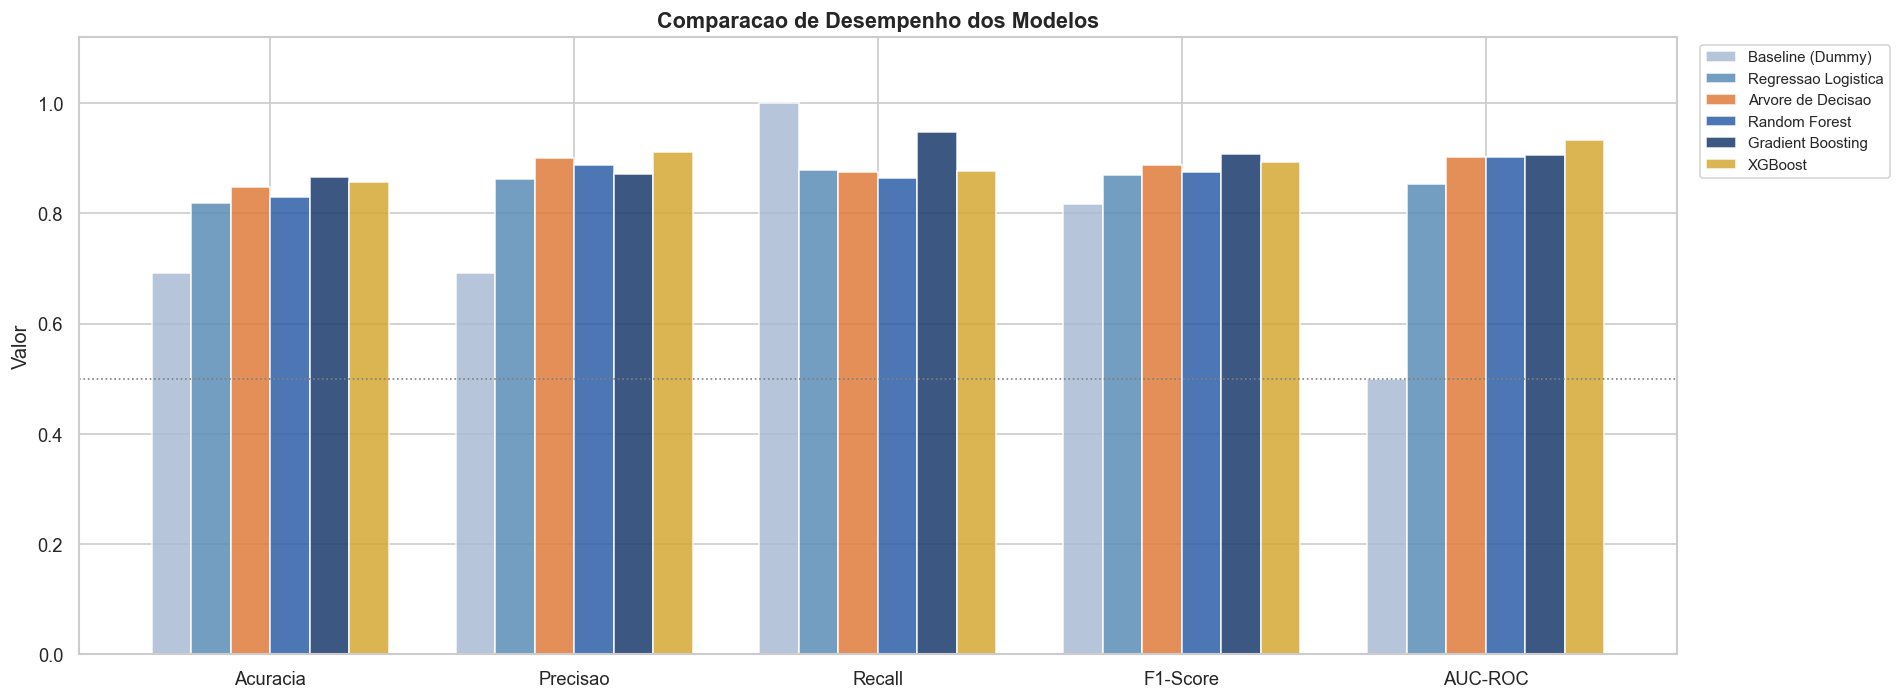

In [255]:
metricas = ['Acuracia','Precisao','Recall','F1-Score','AUC-ROC']
x = np.arange(len(metricas))
width = 0.13
colors_modelos = ['#AABBD4','#5B8DB8','#E07B3A','#2E5EA8','#1A3A6B','#D4A832']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (_, row) in enumerate(df_resultados.iterrows()):
    ax.bar(x + i*width, [row[m] for m in metricas], width,
           label=row['Modelo'], color=colors_modelos[i], alpha=0.85)
ax.set_xticks(x + width*(len(df_resultados)-1)/2)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12); ax.set_ylabel('Valor')
ax.set_title('Comparacao de Desempenho dos Modelos', fontweight='bold', fontsize=13)
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.axhline(0.5, color='gray', linestyle=':', lw=1)
plt.tight_layout()
plt.savefig('fig11_comparacao_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

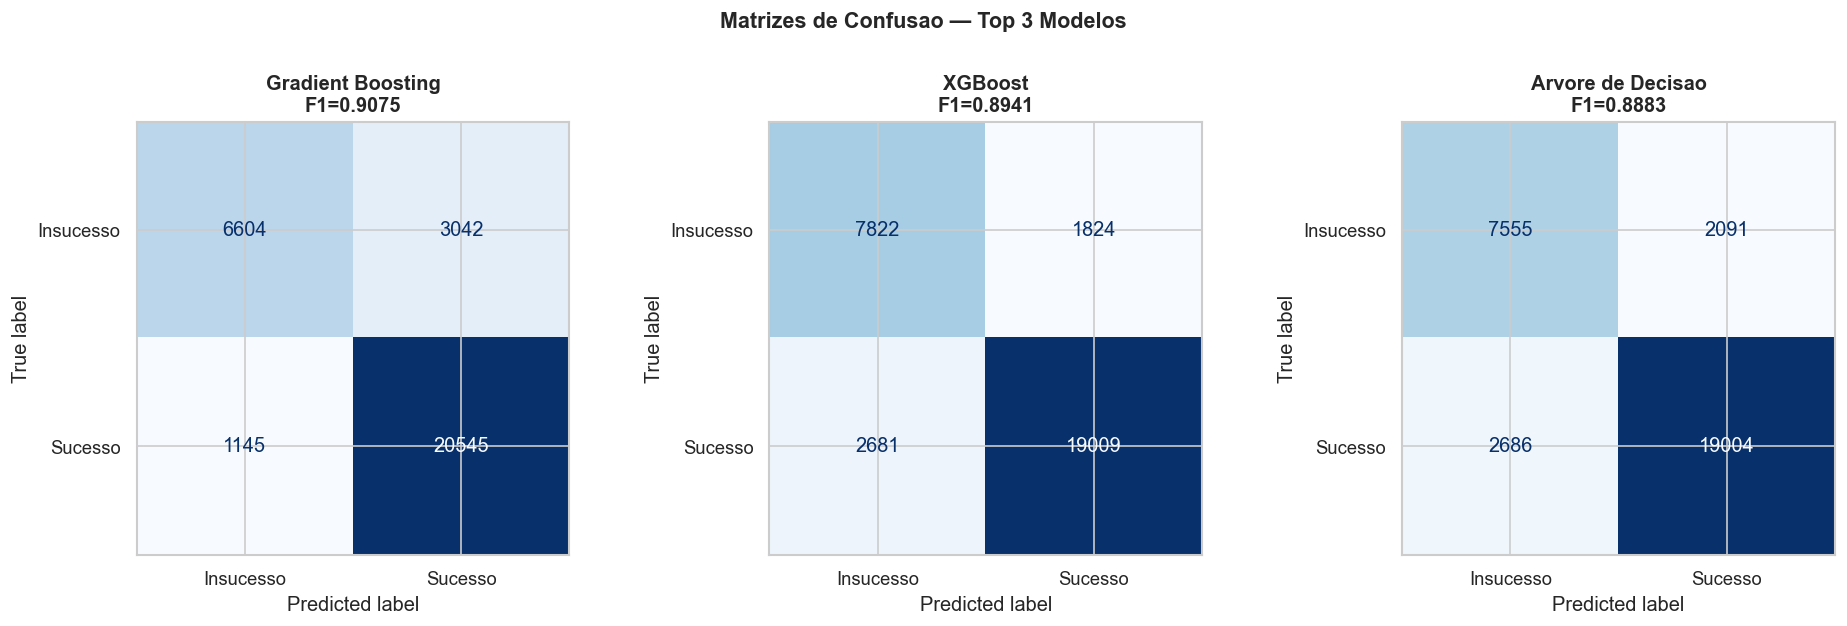

In [256]:
top3 = df_resultados.nlargest(3,'F1-Score')['Modelo'].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, nome in zip(axes, top3):
    y_pred = pipelines_treinados[nome].predict(X_test)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['Insucesso','Sucesso']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{nome}\nF1={f1_score(y_test,y_pred,zero_division=0):.4f}', fontweight='bold')
plt.suptitle('Matrizes de Confusao — Top 3 Modelos', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig12_matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

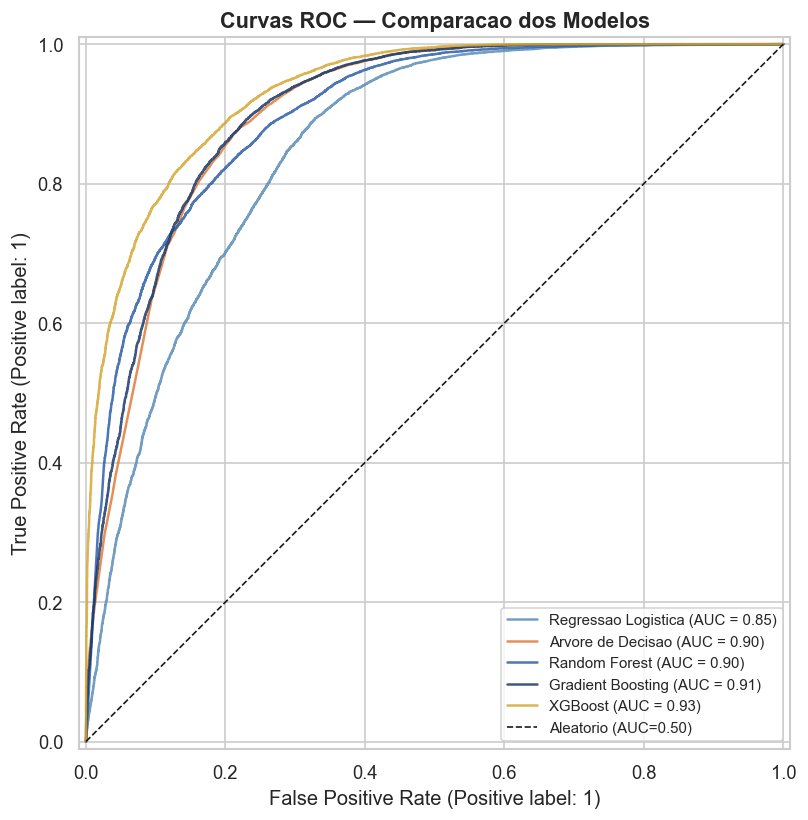

In [257]:
fig, ax = plt.subplots(figsize=(9, 7))
for i, (nome, pipe) in enumerate(pipelines_treinados.items()):
    if nome == 'Baseline (Dummy)': continue
    if hasattr(pipe.named_steps['classifier'], 'predict_proba'):
        RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax,
                                        name=nome, color=colors_modelos[i], alpha=0.85)
ax.plot([0,1],[0,1],'k--', lw=1, label='Aleatorio (AUC=0.50)')
ax.set_title('Curvas ROC — Comparacao dos Modelos', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('fig13_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

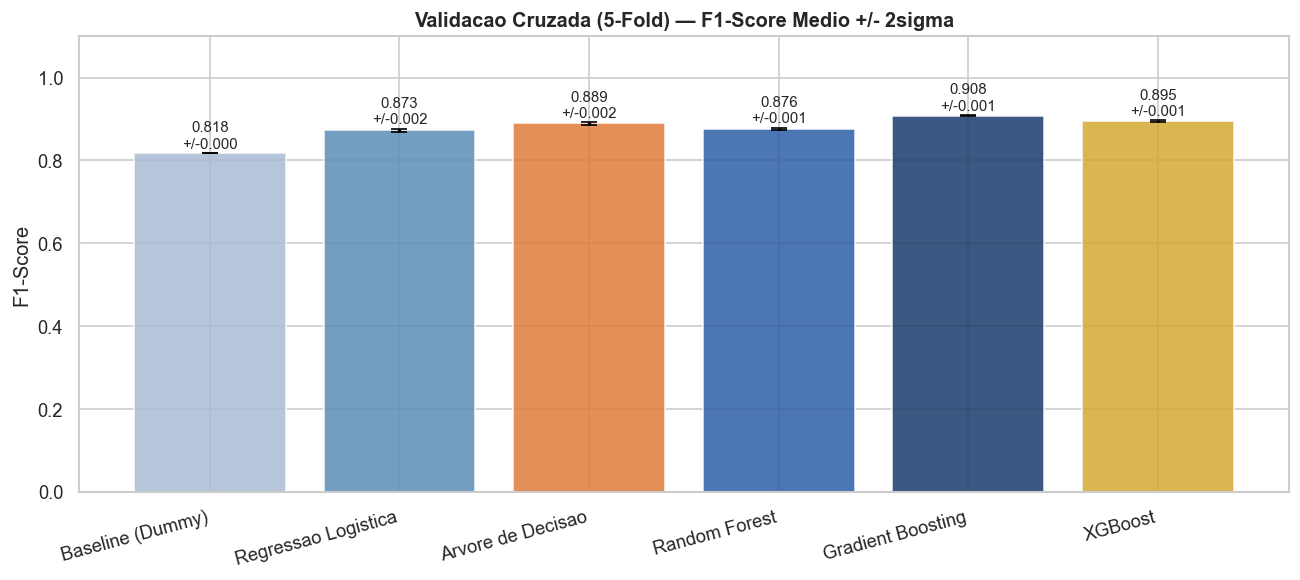

Melhor modelo: Gradient Boosting
              precision    recall  f1-score   support

   Insucesso       0.85      0.68      0.76      9646
     Sucesso       0.87      0.95      0.91     21690

    accuracy                           0.87     31336
   macro avg       0.86      0.82      0.83     31336
weighted avg       0.87      0.87      0.86     31336



In [258]:
fig, ax = plt.subplots(figsize=(11, 5))
nomes  = df_resultados['Modelo']
medias = df_resultados['F1-CV Medio']
stds   = df_resultados['F1-CV Std']
bars = ax.bar(nomes, medias, color=colors_modelos[:len(nomes)], alpha=0.85)
ax.errorbar(nomes, medias, yerr=stds*2, fmt='none', color='black', capsize=5, lw=2)
for bar, val, std in zip(bars, medias, stds):
    ax.text(bar.get_x()+bar.get_width()/2, val+std*2+0.005,
            f'{val:.3f}\n+/-{std:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('F1-Score')
ax.set_title('Validacao Cruzada (5-Fold) — F1-Score Medio +/- 2sigma', fontweight='bold')
ax.set_ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('fig14_cross_validation.png', dpi=150, bbox_inches='tight')
plt.show()

melhor = df_resultados.loc[df_resultados['F1-Score'].idxmax(), 'Modelo']
print(f'Melhor modelo: {melhor}')
print(classification_report(y_test, pipelines_treinados[melhor].predict(X_test),
                             target_names=['Insucesso','Sucesso']))

## 9. Interpretabilidade — Importância das Variáveis

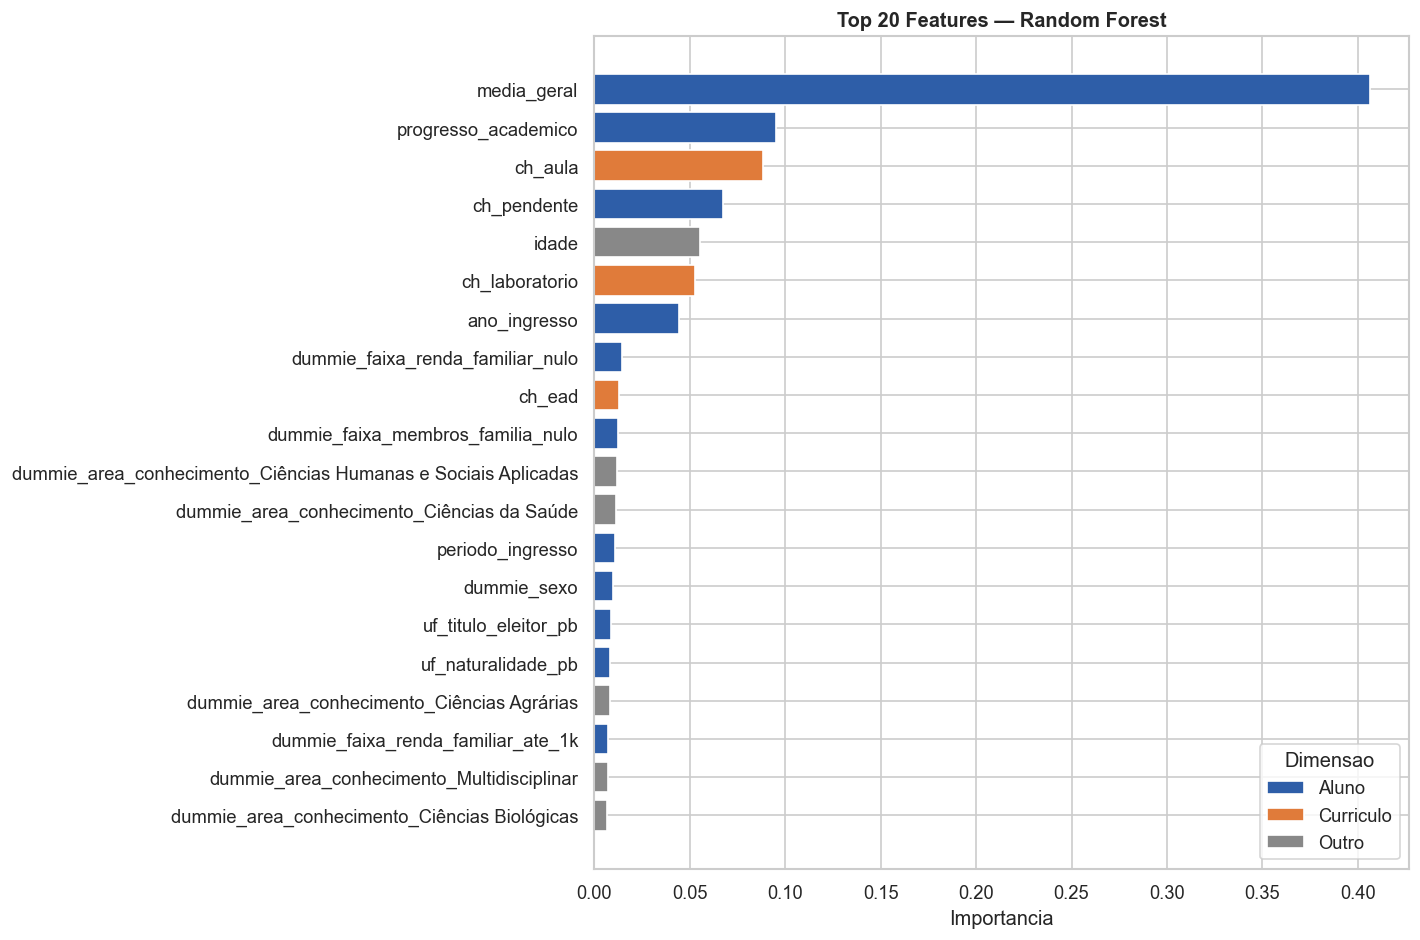


Top 10 features (Random Forest):
  [Aluno     ] media_geral                              0.4064
  [Aluno     ] progresso_academico                      0.0953
  [Curriculo ] ch_aula                                  0.0885
  [Aluno     ] ch_pendente                              0.0673
  [Outro     ] idade                                    0.0554
  [Curriculo ] ch_laboratorio                           0.0526
  [Aluno     ] ano_ingresso                             0.0444
  [Aluno     ] dummie_faixa_renda_familiar_nulo         0.0145
  [Curriculo ] ch_ead                                   0.0132
  [Aluno     ] dummie_faixa_membros_familia_nulo        0.0126


In [259]:
modelos_arvore = ['Random Forest','XGBoost','Gradient Boosting','Arvore de Decisao']
nome_imp = next((m for m in modelos_arvore if m in pipelines_treinados), None)

if nome_imp:
    pipe_imp = pipelines_treinados[nome_imp]
    clf = pipe_imp.named_steps['classifier']
    prep = pipe_imp.named_steps['preprocessor']

    feat_names_all = FEAT_NUM.copy()
    if FEAT_CAT and 'cat' in prep.named_transformers_:
        ohe = prep.named_transformers_['cat'].named_steps['encoder']
        feat_names_all += list(ohe.get_feature_names_out(FEAT_CAT))

    df_imp = pd.DataFrame({'feature': feat_names_all, 'importancia': clf.feature_importances_})
    df_imp = df_imp.sort_values('importancia', ascending=False).head(20)

    def get_bloco(feat):
        f = feat.lower()
        if any(k in f for k in ['sexo','raca','renda','ingresso','familia','ch_integr','ch_pend','media_g','uf_','progress']):
            return 'Aluno'
        if any(k in f for k in ['ch_total','ch_aula','ch_lab','ch_ead','nivel','tipo_comp','qtd_max','campus','turno','prop_ch']):
            return 'Curriculo'
        if any(k in f for k in ['docentes','feminino','admissao','efetivo']):
            return 'Professor'
        return 'Outro'

    df_imp['bloco'] = df_imp['feature'].apply(get_bloco)
    bcolors = {'Aluno':'#2E5EA8','Curriculo':'#E07B3A','Professor':'#27A04B','Outro':'#888'}

    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(df_imp['feature'][::-1], df_imp['importancia'][::-1],
            color=[bcolors[b] for b in df_imp['bloco']][::-1])
    ax.set_xlabel('Importancia')
    ax.set_title(f'Top 20 Features — {nome_imp}', fontweight='bold')
    ax.legend(handles=[Patch(facecolor=c, label=b) for b,c in bcolors.items()
                       if b in df_imp['bloco'].values], title='Dimensao')
    plt.tight_layout()
    plt.savefig('fig15_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\nTop 10 features ({nome_imp}):')
    for _, row in df_imp.head(10).iterrows():
        print(f'  [{row["bloco"]:10}] {row["feature"]:40} {row["importancia"]:.4f}')

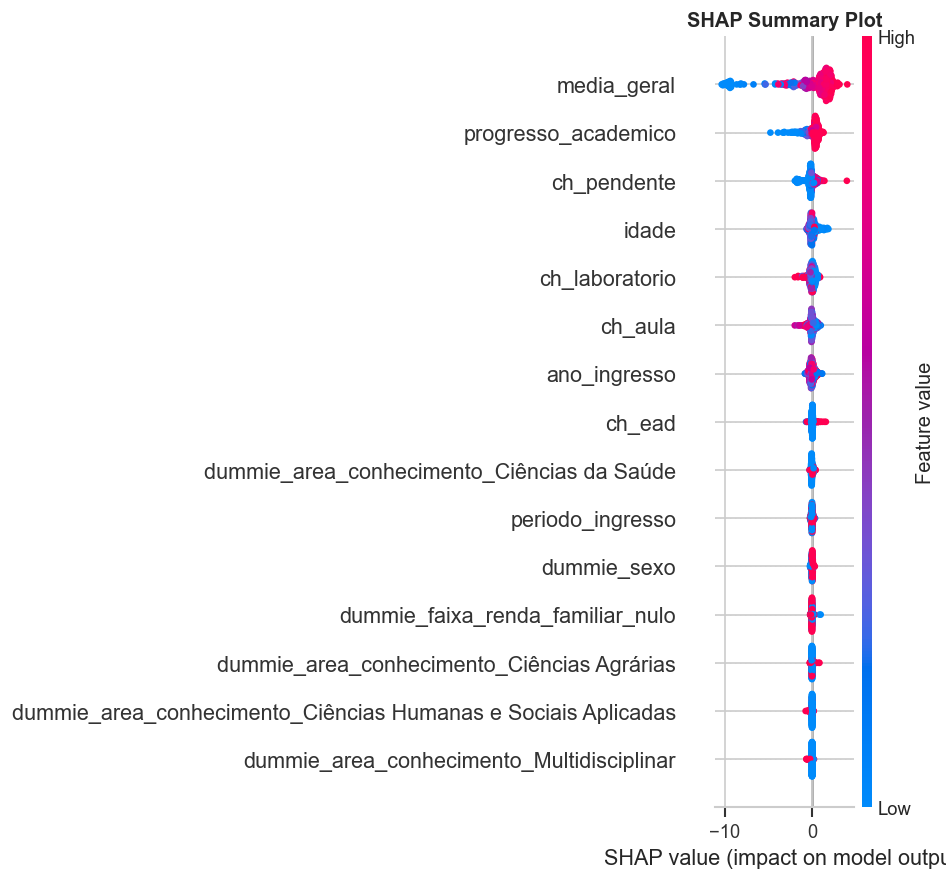

SHAP calculado com sucesso!


In [260]:
try:
    import shap
    pipe_shap = pipelines_treinados.get('XGBoost') or pipelines_treinados.get('Random Forest')
    X_shap = pipe_shap.named_steps['preprocessor'].transform(X_test)[:500]
    explainer   = shap.TreeExplainer(pipe_shap.named_steps['classifier'])
    shap_values = explainer.shap_values(X_shap)
    shap_vals   = shap_values[1] if isinstance(shap_values, list) else shap_values
    plt.figure(figsize=(11, 8))
    shap.summary_plot(shap_vals, X_shap, feature_names=feat_names_all, max_display=15, show=False)
    plt.title('SHAP Summary Plot', fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig16_shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP calculado com sucesso!')
except ImportError:
    print('SHAP nao instalado. Execute: pip install shap')
except Exception as e:
    print(f'SHAP indisponivel: {e}')

## 10. Conclusões Parciais e Próximos Passos

In [261]:
print('=' * 70)
print(' SUMARIO DOS RESULTADOS — ENTREGA PARCIAL')
print('=' * 70)
print(f'\nDataset integrado: {len(df_modelo):,} registros | {len(ALL_FEATURES)} features')
print('3 dimensoes: Aluno, Curriculo, Professor')
print('Variavel-alvo: Binaria (Sucesso / Insucesso)')
print('\nRanking dos modelos (F1-Score):')
df_rank = df_resultados[['Modelo','Acuracia','F1-Score','AUC-ROC','F1-CV Medio']]\
              .sort_values('F1-Score', ascending=False).reset_index(drop=True)
for idx, row in df_rank.iterrows():
    print(f'  {idx+1}. {row["Modelo"]:<25} F1={row["F1-Score"]:.4f}  AUC={row["AUC-ROC"]:.4f}  CV={row["F1-CV Medio"]:.4f}')

print('\nPrincipais observacoes EDA:')
print('  - Dimensao Aluno (renda, raca, forma de ingresso) apresenta variacao significativa na taxa de sucesso')
print('  - Diferenca de desempenho entre CPT-ETS (Joao Pessoa) e CAVN (Bananeiras)')
print('  - Componentes com alta proporcao de CH EaD mostram padrao distinto de aprovacao')
print('  - Departamentos diferem substancialmente em taxa de aprovacao')
print('  - media_geral e ch_integralizada sao os preditores mais fortes do perfil do aluno')

print('\nProximos passos (entrega final):')
print('  1. Otimizacao de hiperparametros (GridSearchCV / Optuna)')
print('  2. Tratamento de desbalanceamento (SMOTE)')
print('  3. Analise SHAP completa por dimensao')
print('  4. Validacao temporal (treinar em anos anteriores, testar no mais recente)')
print('  5. Analise de evasao como segunda variavel-alvo')
print('  6. Dashboard interativo com predicao em tempo real')

 SUMARIO DOS RESULTADOS — ENTREGA PARCIAL

Dataset integrado: 156,679 registros | 43 features
3 dimensoes: Aluno, Curriculo, Professor
Variavel-alvo: Binaria (Sucesso / Insucesso)

Ranking dos modelos (F1-Score):
  1. Gradient Boosting         F1=0.9075  AUC=0.9055  CV=0.9082
  2. XGBoost                   F1=0.8941  AUC=0.9335  CV=0.8946
  3. Arvore de Decisao         F1=0.8883  AUC=0.9019  CV=0.8894
  4. Random Forest             F1=0.8758  AUC=0.9018  CV=0.8765
  5. Regressao Logistica       F1=0.8706  AUC=0.8531  CV=0.8725
  6. Baseline (Dummy)          F1=0.8181  AUC=0.5000  CV=0.8181

Principais observacoes EDA:
  - Dimensao Aluno (renda, raca, forma de ingresso) apresenta variacao significativa na taxa de sucesso
  - Diferenca de desempenho entre CPT-ETS (Joao Pessoa) e CAVN (Bananeiras)
  - Componentes com alta proporcao de CH EaD mostram padrao distinto de aprovacao
  - Departamentos diferem substancialmente em taxa de aprovacao
  - media_geral e ch_integralizada sao os predit